# ZonaAzul — Predicción de supervivencia de escuadrones en PUBG

**Proyecto Integrador · Módulo V**
Diplomado en Ciencia de Datos · Centro de Educación Continua, FES Acatlán, UNAM

---

## Resumen

Este notebook recorre el proyecto completo, de la obtención de datos a los
modelos entrenados:

| Parte | Contenido |
|---|---|
| 1–3 | Obtención desde la API oficial, parseo de telemetría y construcción de la tabla analítica |
| 4–6 | Calidad de los datos y análisis exploratorio univariado, bivariado y multivariado |
| 7–8 | Partición sin fuga y modelación supervisada de referencia |
| 9 | Perfilamiento de estilos de juego mediante agrupamiento |
| 10 | Modelación secuencial con red recurrente |
| 11–13 | Evaluación final, persistencia y conclusiones |

El problema: estimar, en cualquier momento de una partida de PUBG, la
probabilidad de que un escuadrón termine en el cuarto superior de su partida.
La unidad de análisis es el **escuadrón-ventana**: un equipo observado durante
un minuto de juego.

## Reproducibilidad

Se ejecuta de principio a fin en Google Colab sin configuración previa. La celda
de configuración ofrece tres modos:

| Modo | Origen de los datos | Requiere |
|---|---|---|
| `demo` | Simulador incluido en el notebook | Nada |
| `local` | Parquet preprocesado en Google Drive | Enlace público |
| `api` | Descarga en vivo desde la API | Clave gratuita |

El modo por defecto es `demo`, de forma que **cualquier persona puede ejecutar
el notebook completo sin credenciales y sin conexión a servicios externos**.
Los modos `local` y `api` reproducen el análisis sobre los datos reales.

> **Nota sobre el tiempo de ejecución.** En modo `api` la descarga de 150
> partidas tarda varios minutos. Para reproducir el análisis conviene usar
> `local`, que parte del respaldo ya procesado.

## 1. Configuración

In [1]:
# Dependencias (en Colab ya vienen instaladas; se declaran por trazabilidad)
# !pip install -q pandas numpy matplotlib seaborn scikit-learn pyarrow requests

import warnings
warnings.filterwarnings("ignore")

import json, gzip, math, os, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)

# ---------------- Parámetros del estudio ----------------
MODO       = "local"      # "demo" | "local" | "api"
N_PARTIDAS = 300          # en modo api/local, subir a 150
VENTANA    = 60          # segundos por ventana de agregación
T_MAX      = 900         # horizonte de análisis: primeros 15 minutos
MAPA       = "Baltic_Main"   # Erangel
MODO_JUEGO = "squad"

# ---------------- Estilo de las figuras ----------------
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110,
                     "axes.titlesize": 12, "axes.titleweight": "bold"})

BASE = Path("datos"); BASE.mkdir(exist_ok=True)
print(f"Modo: {MODO} | ventana: {VENTANA}s | horizonte: {T_MAX//60} min")

Modo: local | ventana: 60s | horizonte: 15 min


## 2. Fuentes de datos

El proyecto usa tres fuentes, todas ellas interfaces de programación públicas.
Kaggle y los repositorios de datos preprocesados quedan excluidos por requisito
del diplomado.

**Fuente A — PUBG Developer API · Partidas y telemetría.**
Interfaz oficial del estudio Krafton. La clave de acceso es gratuita y se obtiene
en `developer.pubg.com`. Se consumen cuatro recursos:

- `/shards/steam/samples` — muestra de identificadores de partidas recientes, usada
  para construir el conjunto de entrenamiento.
- `/shards/steam/players` — partidas recientes de un jugador concreto, usada por la
  interfaz final para personalizar el análisis.
- `/shards/steam/matches/{id}` — metadatos, composición de escuadrones y **posición
  final**, que constituye la variable objetivo.
- CDN de telemetría — bitácora completa de eventos de la partida.

**Fuente B — PUBG Developer API · Estadísticas de temporada.**
Los recursos `/players/{id}/seasons/{seasonId}` y `/leaderboards` describen el
desempeño histórico acumulado del jugador. Es un producto de datos distinto al
anterior: la telemetría describe *conducta dentro de una partida*, mientras que
estos recursos describen *nivel sostenido del jugador*.

**Fuente C — `pubg/api-assets`.**
Repositorio oficial de diccionarios que traduce los identificadores internos del
motor de juego a nombres legibles. Cumple la función de tabla de catálogo.

### Sobre los límites de consumo

La documentación oficial establece un límite de diez peticiones por minuto para la
clave estándar, con cabeceras `X-RateLimit-Remaining` y `X-RateLimit-Reset` para
monitorearlo. Los recursos `/matches` y la descarga de telemetría **quedan exentos
de ese límite**, lo que hace viable construir un corpus de centenares de partidas
sin negociar cuotas adicionales.

### 2.1 Módulo de acceso y parseo

Se escribe a disco para mantener el notebook legible y permitir su reutilización.

In [2]:
%%writefile zonaazul.py
"""Utilidades del proyecto ZonaAzul: acceso a la API, parseo y simulación."""
from __future__ import annotations
import gzip, json, math, random, time, uuid
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd

BASE_API = "https://api.pubg.com/shards"

# Tamaño de cada mapa en centímetros; las coordenadas de telemetría vienen en cm.
MAP_SIZES_CM = {
    "Baltic_Main": 816_000, "Erangel_Main": 816_000, "Desert_Main": 816_000,
    "Tiger_Main": 816_000, "Kiki_Main": 816_000, "Neon_Main": 816_000,
    "DihorOtok_Main": 612_000, "Savage_Main": 408_000, "Chimera_Main": 306_000,
    "Heaven_Main": 204_000, "Summerland_Main": 204_000, "Range_Main": 204_000,
}

# ====================================================================== #
# 1. Cliente de la API
# ====================================================================== #
class PubgClient:
    """Cliente con limitador de peticiones incorporado."""

    def __init__(self, api_key: str, platform: str = "steam", rpm: int = 10):
        import requests
        self.platform = platform
        self.min_interval = 60.0 / rpm
        self._last = 0.0
        self.session = requests.Session()
        self.session.headers.update({
            "Authorization": f"Bearer {api_key}",
            "Accept": "application/vnd.api+json",
            "Accept-Encoding": "gzip",
        })

    def _get(self, url, limitado=True, reintentos=3):
        for intento in range(reintentos):
            if limitado:
                espera = self.min_interval - (time.time() - self._last)
                if espera > 0:
                    time.sleep(espera)
            r = self.session.get(url, timeout=60)
            if limitado:
                self._last = time.time()
            if r.status_code == 200:
                return r.json()
            if r.status_code == 429:                       # cuota agotada
                reset = int(r.headers.get("X-RateLimit-Reset", 0))
                time.sleep(max(5, reset - int(time.time())) if reset else 15)
                continue
            if r.status_code == 404:
                raise FileNotFoundError(url)               # partida expirada
            if r.status_code >= 500:
                time.sleep(2 ** intento)
                continue
            raise RuntimeError(f"HTTP {r.status_code}: {r.text[:200]}")
        raise RuntimeError(f"Reintentos agotados: {url}")

    def samples(self, since=None):
        """Muestra de partidas recientes. Es el recurso limitado por cuota."""
        url = f"{BASE_API}/{self.platform}/samples"
        if since:
            url += f"?filter[createdAt-start]={since}"
        d = self._get(url, limitado=True)
        return [m["id"] for m in d["data"]["relationships"]["matches"]["data"]]

    def match(self, match_id):
        """Metadatos de partida. Exento del límite de cuota."""
        return self._get(f"{BASE_API}/{self.platform}/matches/{match_id}", limitado=False)

    @staticmethod
    def telemetry_url(match_json):
        aid = match_json["data"]["relationships"]["assets"]["data"][0]["id"]
        for it in match_json["included"]:
            if it["type"] == "asset" and it["id"] == aid:
                return it["attributes"]["URL"]
        raise KeyError("asset de telemetría ausente")

    def descargar_telemetria(self, url, destino):
        import requests
        destino = Path(destino); destino.parent.mkdir(parents=True, exist_ok=True)
        r = requests.get(url, headers={"Accept-Encoding": "gzip"}, timeout=180)
        r.raise_for_status()
        with gzip.open(destino, "wt", encoding="utf-8") as f:
            f.write(r.text)
        return destino


# ====================================================================== #
# 2. Parseo (Fase 1)
# ====================================================================== #
def parsear_meta(meta_json, match_id):
    """Extrae participantes y posición final. Aquí viven las etiquetas."""
    attrs = meta_json["data"]["attributes"]
    incl  = meta_json.get("included", [])
    parts = {i["id"]: i for i in incl if i["type"] == "participant"}
    filas = []
    for r in [i for i in incl if i["type"] == "roster"]:
        st = r["attributes"].get("stats", {})
        for p in r["relationships"]["participants"]["data"]:
            pa = parts.get(p["id"], {}).get("attributes", {}).get("stats", {})
            filas.append({
                "match_id": match_id, "team_id": st.get("teamId"),
                "team_rank": st.get("rank"),
                "won": str(r["attributes"].get("won", "false")).lower() == "true",
                "account_id": pa.get("playerId"), "name": pa.get("name"),
                "kills": pa.get("kills"), "damage_dealt": pa.get("damageDealt"),
                "time_survived": pa.get("timeSurvived"),
                "walk_distance": pa.get("walkDistance"),
            })
    info = {"match_id": match_id, "map_name": attrs.get("mapName"),
            "game_mode": attrs.get("gameMode"), "duration": attrs.get("duration")}
    df = pd.DataFrame(filas)
    for k, v in info.items():
        if k != "match_id":
            df[k] = v
    return df, info


def parsear_telemetria(eventos, match_id, map_name):
    """Recorre la bitácora una sola vez y llena tres tablas planas."""
    escala = MAP_SIZES_CM.get(map_name, 816_000)
    pos, zona, muertes = [], [], []

    for ev in eventos:
        t = ev.get("_T")

        if t == "LogPlayerPosition":
            ch  = ev.get("character") or {}
            loc = ch.get("location") or {}
            x, y = loc.get("x"), loc.get("y")
            pos.append({
                "match_id": match_id, "t": ev.get("elapsedTime"),
                "account_id": ch.get("accountId"), "team_id": ch.get("teamId"),
                "health": ch.get("health"),
                "x_norm": x / escala if x is not None else None,
                "y_norm": y / escala if y is not None else None,
                "in_blue_zone": ch.get("isInBlueZone"),
                "num_alive": ev.get("numAlivePlayers"),
            })

        elif t == "LogGameStatePeriodic":
            gs = ev.get("gameState") or {}
            sz = gs.get("safetyZonePosition") or {}
            zona.append({
                "match_id": match_id, "t": gs.get("elapsedTime"),
                "safety_x_norm": sz.get("x") / escala if sz.get("x") is not None else None,
                "safety_y_norm": sz.get("y") / escala if sz.get("y") is not None else None,
                "safety_r_norm": (gs.get("safetyZoneRadius") or 0) / escala,
                "num_alive_teams": gs.get("numAliveTeams"),
                "num_alive_players": gs.get("numAlivePlayers"),
            })

        # La API usa LogPlayerKillV2 en versiones recientes y LogPlayerKill en
        # partidas antiguas: se admiten ambas.
        elif t in ("LogPlayerKillV2", "LogPlayerKill"):
            v  = ev.get("victim") or {}
            k  = ev.get("killer") or ev.get("finisher") or {}
            di = ev.get("finishDamageInfo") or {}
            vl = v.get("location") or {}
            muertes.append({
                "match_id": match_id, "ts": ev.get("_D"),
                "victim_team": v.get("teamId"), "killer_team": k.get("teamId"),
                "victim_x_norm": vl.get("x") / escala if vl.get("x") is not None else None,
                "victim_y_norm": vl.get("y") / escala if vl.get("y") is not None else None,
                "damage_reason": di.get("damageReason") or ev.get("damageReason"),
                "damage_category": di.get("damageTypeCategory") or ev.get("damageTypeCategory"),
                "distance": di.get("distance") or ev.get("distance"),
            })

    return {"posiciones": pd.DataFrame(pos), "zona": pd.DataFrame(zona),
            "muertes": pd.DataFrame(muertes)}


# ====================================================================== #
# 3. Simulador (modo demo)
# ====================================================================== #
def simular_partida(n_equipos=25, por_equipo=4, duracion=1500, semilla=None):
    """
    Genera una partida con la misma estructura que devuelve la API real.

    Cada equipo recibe una habilidad latente que gobierna simultáneamente su
    velocidad de rotación hacia la zona segura y su supervivencia. La asociación
    entre conducta y resultado emerge de ese parámetro común, no se impone.
    """
    rnd = random.Random(semilla)
    mid = str(uuid.uuid4())
    t0  = datetime(2026, 8, 25, 20, 0, 0)
    ts  = lambda s: (t0 + timedelta(seconds=s)).strftime("%Y-%m-%dT%H:%M:%S.000Z")

    habilidad = {e: rnd.betavariate(2, 2) for e in range(1, n_equipos + 1)}
    orden = sorted(range(1, n_equipos + 1),
                   key=lambda e: habilidad[e] + rnd.gauss(0, 0.12))
    ganador = orden[-1]
    muerte = {e: 120 + (i / n_equipos) * (duracion - 150) + rnd.uniform(-40, 40)
              for i, e in enumerate(orden)}
    muerte[ganador] = duracion + 999

    jug = [{"accountId": f"account.{uuid.uuid4().hex}", "name": f"j{e}_{k}",
            "teamId": e, "x": rnd.uniform(.1, .9) * 816_000,
            "y": rnd.uniform(.1, .9) * 816_000, "health": 100.0,
            "muere": muerte[e] + rnd.uniform(-25, 25)}
           for e in range(1, n_equipos + 1) for k in range(por_equipo)]

    cx, cy = rnd.uniform(.35, .65) * 816_000, rnd.uniform(.35, .65) * 816_000
    radio = lambda t: max(.02, 1 - (t / duracion) ** 1.3) * 816_000 * .5

    eventos, muertos = [], set()
    for t in range(0, duracion + 1, 5):
        r = radio(t)
        vivos = [p for p in jug if t < p["muere"]]
        eventos.append({"_D": ts(t), "_T": "LogGameStatePeriodic", "gameState": {
            "elapsedTime": t, "numAliveTeams": len({p["teamId"] for p in vivos}),
            "numAlivePlayers": len(vivos),
            "safetyZonePosition": {"x": cx, "y": cy, "z": 0}, "safetyZoneRadius": r,
            "poisonGasWarningPosition": {"x": cx, "y": cy, "z": 0},
            "poisonGasWarningRadius": r * .7}})

        if t % 10 == 0:
            for p in vivos:
                dx, dy = cx - p["x"], cy - p["y"]
                d = math.hypot(dx, dy) or 1
                paso = min(d, rnd.uniform(0, 2000 + 5000 * habilidad[p["teamId"]]))
                p["x"] += dx / d * paso + rnd.uniform(-800, 800)
                p["y"] += dy / d * paso + rnd.uniform(-800, 800)
                fuera = math.hypot(p["x"] - cx, p["y"] - cy) > r
                if fuera:
                    p["health"] = max(1.0, p["health"] - rnd.uniform(0, 3))
                eventos.append({"_D": ts(t), "_T": "LogPlayerPosition",
                    "elapsedTime": t, "numAlivePlayers": len(vivos), "character": {
                        "name": p["name"], "teamId": p["teamId"],
                        "health": round(p["health"], 1), "accountId": p["accountId"],
                        "location": {"x": p["x"], "y": p["y"], "z": 100.0},
                        "isInBlueZone": bool(fuera), "isInRedZone": False}})

        for p in jug:
            if p["accountId"] not in muertos and t >= p["muere"]:
                muertos.add(p["accountId"])
                cand = [q for q in vivos if q["teamId"] != p["teamId"]]
                k = rnd.choice(cand) if cand else None
                eventos.append({"_D": ts(t), "_T": "LogPlayerKillV2",
                    "victim": {"name": p["name"], "teamId": p["teamId"],
                               "accountId": p["accountId"],
                               "location": {"x": p["x"], "y": p["y"], "z": 100.0}},
                    "killer": ({"name": k["name"], "teamId": k["teamId"],
                                "accountId": k["accountId"]} if k else None),
                    "finishDamageInfo": {
                        "damageReason": rnd.choice(["HeadShot", "TorsoShot", "PelvisShot"]),
                        "damageTypeCategory": rnd.choice(
                            ["Damage_Gun", "Damage_Groggy", "Damage_BlueZone"]),
                        "distance": round(rnd.uniform(500, 30000), 1)}})

    rank = {e: n_equipos - i for i, e in enumerate(orden)}
    incl = []
    for e in range(1, n_equipos + 1):
        pids = []
        for p in [x for x in jug if x["teamId"] == e]:
            pid = str(uuid.uuid4()); pids.append({"type": "participant", "id": pid})
            incl.append({"type": "participant", "id": pid, "attributes": {"stats": {
                "playerId": p["accountId"], "name": p["name"],
                "kills": rnd.randint(0, 6), "damageDealt": round(rnd.uniform(0, 900), 1),
                "timeSurvived": round(min(p["muere"], duracion), 1),
                "walkDistance": round(rnd.uniform(200, 4000), 1),
                "winPlace": rank[e]}}})
        incl.append({"type": "roster", "id": str(uuid.uuid4()),
            "attributes": {"stats": {"rank": rank[e], "teamId": e},
                           "won": "true" if e == ganador else "false"},
            "relationships": {"participants": {"data": pids}}})
    aid = str(uuid.uuid4())
    incl.append({"type": "asset", "id": aid,
                 "attributes": {"URL": "https://telemetry-cdn.pubg.com/demo.json"}})

    meta = {"data": {"type": "match", "id": mid, "attributes": {
        "mapName": "Baltic_Main", "gameMode": "squad", "duration": duracion,
        "isCustomMatch": False, "createdAt": ts(0)},
        "relationships": {"assets": {"data": [{"type": "asset", "id": aid}]}}},
        "included": incl}
    return eventos, meta, mid

Overwriting zonaazul.py


### 2.2 Obtención

Una sola función resuelve los tres modos, de forma que el resto del notebook es idéntico sin importar el origen de los datos.

In [3]:
import zonaazul as za

def obtener_datos(modo=MODO, n=N_PARTIDAS):
    """Devuelve (posiciones, zona, muertes, participantes) según el modo activo."""
    modo = str(modo).strip().lower()      # tolera "API", "Api", " api "
    pos_l, zona_l, mue_l, part_l, info_l = [], [], [], [], []

    if modo == "demo":
        for i in range(n):
            ev, meta, mid = za.simular_partida(semilla=SEMILLA + i)
            dfp, info = za.parsear_meta(meta, mid)
            tb = za.parsear_telemetria(ev, mid, info["map_name"])
            pos_l.append(tb["posiciones"]); zona_l.append(tb["zona"])
            mue_l.append(tb["muertes"]);    part_l.append(dfp); info_l.append(info)

    elif modo == "local":
        # Respaldo preprocesado. Garantiza que el análisis sea reproducible
        # aunque la API esté fuera de servicio.
        # !gdown --folder <ID_CARPETA_DRIVE> -O datos/
        for t, acc in [("posiciones", pos_l), ("zona", zona_l),
                       ("muertes", mue_l), ("participantes", part_l)]:
            acc.append(pd.read_parquet(BASE / f"{t}.parquet"))

    elif modo == "api":
        from pathlib import Path          # en Colab: Secrets
        cli = za.PubgClient(Path("pubg_key.txt").read_text().strip())
        ids = cli.samples(); random.shuffle(ids)
        obtenidas = 0
        for mid in ids:
            if obtenidas >= n:
                break
            try:
                mj = cli.match(mid)
                a  = mj["data"]["attributes"]
                if a.get("mapName") != MAPA or a.get("gameMode") != MODO_JUEGO \
                   or a.get("isCustomMatch"):
                    continue
                dest = cli.descargar_telemetria(cli.telemetry_url(mj),
                                                BASE / "raw" / f"{mid}.json.gz")
                with gzip.open(dest, "rt", encoding="utf-8") as f:
                    ev = json.load(f)
                dfp, info = za.parsear_meta(mj, mid)
                tb = za.parsear_telemetria(ev, mid, info["map_name"])
                pos_l.append(tb["posiciones"]); zona_l.append(tb["zona"])
                mue_l.append(tb["muertes"]);    part_l.append(dfp); info_l.append(info)
                obtenidas += 1
            except Exception as e:
                print(f"  omitida {mid[:8]}: {type(e).__name__}")
    else:
        raise ValueError(f"Modo desconocido: {modo}")

    cat = lambda L: pd.concat(L, ignore_index=True)
    return cat(pos_l), cat(zona_l), cat(mue_l), cat(part_l)


posiciones, zona, muertes, participantes = obtener_datos()

print(f"Partidas          : {posiciones.match_id.nunique()}")
print(f"Posiciones        : {len(posiciones):,} filas")
print(f"Estados de zona   : {len(zona):,} filas")
print(f"Bajas             : {len(muertes):,} filas")
print(f"Participantes     : {len(participantes):,} filas")

Partidas          : 150
Posiciones        : 1,110,787 filas
Estados de zona   : 22,581 filas
Bajas             : 14,074 filas
Participantes     : 14,128 filas


## 3. Construcción de la tabla analítica

La telemetría es una **bitácora de eventos**: cada renglón describe algo que
ocurrió, no una observación comparable con las demás. Antes de cualquier análisis
hay que decidir cuál es la unidad de observación. Aquí se define como el
**equipo-ventana**: un escuadrón observado durante un minuto de juego.

La transformación tiene dos pasos. Primero se cruzan las posiciones de los
jugadores con el estado del círculo vigente en ese instante, mediante una unión
por proximidad temporal hacia atrás. Después se agregan los jugadores de un mismo
escuadrón dentro de cada ventana.

El horizonte se recorta a los primeros quince minutos por dos razones. La primera
es de diseño: la utilidad del sistema está en avisar mientras la partida puede
corregirse, no en explicar un desenlace consumado. La segunda es estadística: más
allá de ese punto quedan pocos equipos vivos y las ventanas tardías se vuelven
escasas y poco representativas.

In [4]:
# --- Paso 1: estado del círculo vigente para cada observación de posición -----
posiciones = posiciones.sort_values("t")
zona       = zona.sort_values("t")

df = pd.merge_asof(posiciones, zona, on="t", by="match_id", direction="backward")

# --- Paso 2: variables geométricas -------------------------------------------
df["dist_centro"] = np.hypot(df.x_norm - df.safety_x_norm,
                             df.y_norm - df.safety_y_norm)
# Distancia relativa: <1 significa dentro de la zona segura, >1 fuera.
# Normalizar por el radio la hace comparable entre fases de la partida.
df["dist_rel"]   = df.dist_centro / df.safety_r_norm.replace(0, np.nan)
df["fuera_zona"] = (df.dist_rel > 1).astype(int)
df["ventana"]    = (df.t // VENTANA).astype(int)
df = df[df.t < T_MAX]

# --- Paso 3: agregación por escuadrón y ventana ------------------------------
agg = (df.groupby(["match_id", "team_id", "ventana"])
         .agg(jugadores_vivos=("account_id", "nunique"),
              tam_escuadron=("account_id", "nunique"),
              hp_medio=("health", "mean"),
              hp_minimo=("health", "min"),
              dist_centro=("dist_centro", "mean"),
              dist_rel=("dist_rel", "mean"),
              frac_fuera=("fuera_zona", "mean"),
              radio_zona=("safety_r_norm", "mean"),
              equipos_vivos=("num_alive_teams", "min"))
         .reset_index())

# Desplazamiento del centroide: proxy de rotación
cen = (df.groupby(["match_id", "team_id", "ventana"])[["x_norm", "y_norm"]]
         .mean().reset_index())
cen[["dx", "dy"]] = cen.groupby(["match_id", "team_id"])[["x_norm", "y_norm"]].diff()
cen["desplazamiento"] = np.hypot(cen.dx, cen.dy)
agg = agg.merge(cen[["match_id", "team_id", "ventana", "desplazamiento"]],
                on=["match_id", "team_id", "ventana"], how="left")

# --- Paso 4: etiquetas --------------------------------------------------------
etq = (participantes.groupby(["match_id", "team_id"])
                    .agg(team_rank=("team_rank", "first")).reset_index())
agg = agg.merge(etq, on=["match_id", "team_id"], how="left")

# Número de escuadrones por partida: varía entre 20 y 46 según cuánta
# gente entre sola o en pareja al modo de escuadrón. Sin normalizar,
# "top 10" significa el 38% superior en una partida y el 22% en otra.
n_rosters = (participantes.groupby("match_id").team_id
                          .nunique().rename("n_rosters"))
tam = agg.groupby(["match_id","team_id"]).tam_escuadron.max().rename("tam_real")
agg = agg.drop(columns="tam_escuadron").merge(tam, on=["match_id","team_id"], how="left")
agg = agg.merge(n_rosters, on="match_id", how="left")

# Posición relativa: 0 = ganador, 1 = último lugar
agg["pct_rank"] = (agg.team_rank - 1) / (agg.n_rosters - 1)
agg["top25"]    = (agg.pct_rank <= 0.25).astype(int)   # objetivo principal
agg["top10"]    = (agg.team_rank <= 10).astype(int)    # se conserva para comparar
agg["top1"]     = (agg.team_rank == 1).astype(int)

# --- Paso 5: fase de la zona --------------------------------------------------
# El radio del círculo no decrece de forma continua: avanza por fases discretas,
# visibles como picos en su histograma. Cada partida entra en fase en un momento
# distinto, de modo que el minuto de reloj NO es comparable entre partidas. La
# fase sí lo es, y constituye el reloj real del juego.
agg["fase_zona"] = pd.cut(agg.radio_zona,
                          bins=[0, .15, .25, .35, .45, .60, .80],
                          labels=[6, 5, 4, 3, 2, 1]).astype(float)

print(f"Tabla analítica: {agg.shape[0]:,} filas × {agg.shape[1]} columnas")
print(f"Equipos únicos : {agg.groupby(['match_id','team_id']).ngroups:,}")
agg.head()

Tabla analítica: 46,886 filas × 20 columnas
Equipos únicos : 3,931


,match_id,team_id,ventana,jugadores_vivos,hp_medio,hp_minimo,dist_centro,dist_rel,frac_fuera,radio_zona,equipos_vivos,desplazamiento,team_rank,tam_real,n_rosters,pct_rank,top25,top10,top1,fase_zona
0,00655377-a20b-488e-b859-cc8f89995e2a,1,0,4,100.000000,100.000000,0.354632,0.497216,0.0,0.713234,16.0,NaN,15.0,4,16,0.933333,0,0,0,1.0
1,00655377-a20b-488e-b859-cc8f89995e2a,1,1,4,100.000000,100.000000,0.297360,0.416918,0.0,0.713234,16.0,0.357862,15.0,4,16,0.933333,0,0,0,1.0
2,00655377-a20b-488e-b859-cc8f89995e2a,1,2,4,94.150917,47.122002,0.292097,0.409539,0.0,0.713234,16.0,0.005568,15.0,4,16,0.933333,0,0,0,1.0
3,00655377-a20b-488e-b859-cc8f89995e2a,1,3,4,97.625000,84.500000,0.288203,0.404079,0.0,0.713234,16.0,0.006132,15.0,4,16,0.933333,0,0,0,1.0
4,00655377-a20b-488e-b859-cc8f89995e2a,1,4,4,97.735854,83.832100,0.281257,0.401342,0.0,0.700780,15.0,0.004979,15.0,4,16,0.933333,0,0,0,1.0


### 3.1 Diccionario de variables

| Variable | Tipo | Descripción | Rango |
|---|---|---|---|
| `match_id` | id | Identificador de partida | — |
| `team_id` | id | Identificador de escuadrón dentro de la partida | 1–46 |
| `ventana` | ordinal | Minuto de juego transcurrido | 0–14 |
| `fase_zona` | ordinal | Fase de contracción del círculo | 1–6 |
| `jugadores_vivos` | discreta | Miembros del escuadrón con vida | 0–5 |
| `tam_real` | discreta | Tamaño inicial del escuadrón | 1–5 |
| `hp_medio` | continua | Salud promedio del escuadrón | 0–100 |
| `hp_minimo` | continua | Salud del miembro más comprometido | 0–100 |
| `dist_centro` | continua | Distancia del centroide al centro de la zona, normalizada | 0–0.7 |
| `dist_rel` | continua | Distancia anterior dividida entre el radio vigente | 0–∞ |
| `frac_fuera` | continua | Proporción de observaciones del escuadrón fuera de la zona | 0–1 |
| `radio_zona` | continua | Radio de la zona segura, normalizado | 0–0.72 |
| `equipos_vivos` | discreta | Escuadrones restantes en la partida | 1–46 |
| `desplazamiento` | continua | Movimiento del centroide respecto de la ventana previa | 0–1 |
| `n_rosters` | discreta | Escuadrones que iniciaron la partida | 15–46 |
| `team_rank` | discreta | Posición final del escuadrón | 1–46 |
| `pct_rank` | continua | Posición final normalizada: 0 = ganador, 1 = último | 0–1 |
| `top25` | binaria | **Objetivo:** el escuadrón termina en el cuarto superior | 0/1 |
| `top10` | binaria | Objetivo alterno sin normalizar, para comparación | 0/1 |
| `top1` | binaria | Objetivo secundario: victoria | 0/1 |

### 3.2 Por qué la posición se normaliza

El número de escuadrones por partida no es constante: oscila entre 15 y 46,
porque en la modalidad de escuadrón muchos jugadores entran solos o en pareja y
forman equipos incompletos. Terminar entre los diez primeros de 26 escuadrones
significa quedar en el 38 % superior; hacerlo entre 46 significa quedar en el
22 %. Una etiqueta absoluta mezclaría dos niveles de dificultad bajo el mismo
nombre y el modelo aprendería, en parte, el tamaño de la partida.

Por ello la variable objetivo se define sobre la **posición relativa**: el
escuadrón clasifica si termina en el cuarto superior de su propia partida.

### 3.3 Por qué la fase importa más que el minuto

El radio de la zona segura no decrece de forma continua sino por fases
programadas, visibles como picos aislados en su histograma. Cada partida entra
en cada fase en un momento distinto del reloj, de modo que dos escuadrones
observados en el minuto diez pueden encontrarse en situaciones incomparables:
uno con el círculo aún abierto y otro ya encerrado.

La fase de la zona es, por tanto, el reloj efectivo del juego, y se emplea como
eje temporal del análisis en lugar del minuto transcurrido.

### 3.4 Advertencia sobre fuga de información

La tabla de participantes contiene atributos que **solo existen al final de la
partida**: tiempo de supervivencia, bajas totales, daño infligido y distancia
recorrida. Incorporarlos como predictores produciría un desempeño
artificialmente alto y un modelo inservible en producción, porque en el minuto
diez esa información no existe todavía.

Se excluyen deliberadamente del conjunto de predictores. Su uso queda
restringido al perfilamiento no supervisado de estilos de juego, donde describir
la partida completa sí es legítimo.

## 4. Calidad de los datos

In [5]:
# --- Valores ausentes ---------------------------------------------------------
aus = pd.DataFrame({
    "ausentes": agg.isna().sum(),
    "porcentaje": (agg.isna().mean() * 100).round(2),
}).query("ausentes > 0")

print("Valores ausentes:")
display(aus if len(aus) else "Sin valores ausentes.")

# El desplazamiento es nulo por construcción en la primera ventana de cada
# escuadrón: no existe ventana previa contra la cual compararlo. No es un
# defecto del dato sino una consecuencia de la definición de la variable,
# por lo que se imputa con cero en lugar de descartar la observación.
agg["desplazamiento"] = agg.desplazamiento.fillna(0)

# --- Consistencia de las etiquetas -------------------------------------------
chk = participantes.groupby("match_id").agg(
    equipos=("team_id", "nunique"),
    rank_min=("team_rank", "min"),
    rank_max=("team_rank", "max"),
    ganadores=("won", "sum"))
print("\nVerificación de integridad por partida:")
print(f"  Partidas con exactamente un escuadrón ganador: "
      f"{(chk.ganadores > 0).sum()}/{len(chk)}")
print(f"  Rango de posiciones: {chk.rank_min.min()} a {chk.rank_max.max()}")
print(f"  Escuadrones por partida (mediana): {chk.equipos.median():.0f}")

# --- Balance de la variable objetivo -----------------------------------------
# Se mide a nivel ESCUADRÓN, no a nivel escuadrón-ventana: los equipos que
# sobreviven más tiempo aportan más filas y sesgarían el promedio directo.
eq = agg.drop_duplicates(["match_id", "team_id"])
print(f"\nBalance de clases a nivel escuadrón:")
print(f"  top25 = 1 : {eq.top25.mean():.1%}")
print(f"  top1  = 1 : {eq.top1.mean():.1%}")

Valores ausentes:


,ausentes,porcentaje
dist_centro,69,0.15
dist_rel,69,0.15
radio_zona,69,0.15
equipos_vivos,69,0.15
desplazamiento,3931,8.38
team_rank,62,0.13
pct_rank,62,0.13
fase_zona,69,0.15



Verificación de integridad por partida:
  Partidas con exactamente un escuadrón ganador: 150/150
  Rango de posiciones: 1 a 38
  Escuadrones por partida (mediana): 26

Balance de clases a nivel escuadrón:
  top25 = 1 : 26.0%
  top1  = 1 : 3.8%


**Desbalance.** La proporción de escuadrones que ganan la partida ronda el
cuatro por ciento. Un clasificador que prediga siempre la clase mayoritaria
alcanzaría una exactitud del noventa y seis por ciento sin haber aprendido nada.
Por ello el análisis se apoya en el área bajo la curva ROC y en el puntaje de
Brier en lugar de la exactitud, y la variable objetivo principal es `top25`,
cuya proporción cercana a la cuarta parte resulta manejable.

**Sesgo de supervivencia.** La tabla anterior expone una propiedad estructural
del problema que condiciona todo lo que sigue: la tabla analítica solo contiene
escuadrones vivos, porque los eliminados dejan de generar registros de posición.
En consecuencia, la proporción de escuadrones destinados al cuarto superior
crece de forma monótona conforme avanza la partida.

Esto no es un defecto del muestreo sino la naturaleza del fenómeno, y obliga a
reformular la pregunta. El sistema no responde «¿va a ganar este escuadrón?»
sino «**dado que este escuadrón sigue vivo en la fase $t$, ¿va a llegar al
cuarto superior?**». Para una herramienta de entrenamiento esa es, además, la
pregunta útil.

## 5. Análisis exploratorio

El análisis persigue tres finalidades: verificar la calidad e integridad del
corpus, establecer si existe asociación entre la conducta observable y el
desenlace, y caracterizar la estructura de dependencia entre predictores con
vistas a la etapa de modelado.

### 5.1 Estructura temporal de la partida

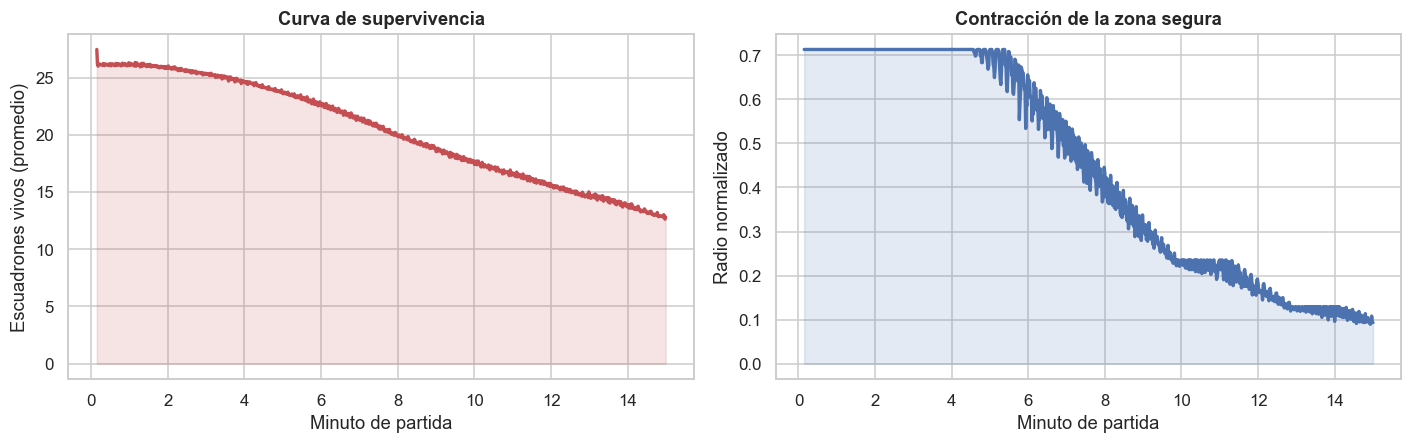

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# Curva de supervivencia
sup = df.groupby("t").num_alive_teams.mean()
axes[0].plot(sup.index / 60, sup.values, lw=2.2, color="#c44e52")
axes[0].set(xlabel="Minuto de partida", ylabel="Escuadrones vivos (promedio)",
            title="Curva de supervivencia")
axes[0].fill_between(sup.index / 60, sup.values, alpha=.15, color="#c44e52")

# Contracción de la zona segura
rz = zona[zona.t <= T_MAX].groupby("t").safety_r_norm.mean()
axes[1].plot(rz.index / 60, rz.values, lw=2.2, color="#4c72b0")
axes[1].set(xlabel="Minuto de partida", ylabel="Radio normalizado",
            title="Contracción de la zona segura")
axes[1].fill_between(rz.index / 60, rz.values, alpha=.15, color="#4c72b0")

plt.tight_layout(); plt.show()

### 5.2 Distribución de las variables continuas

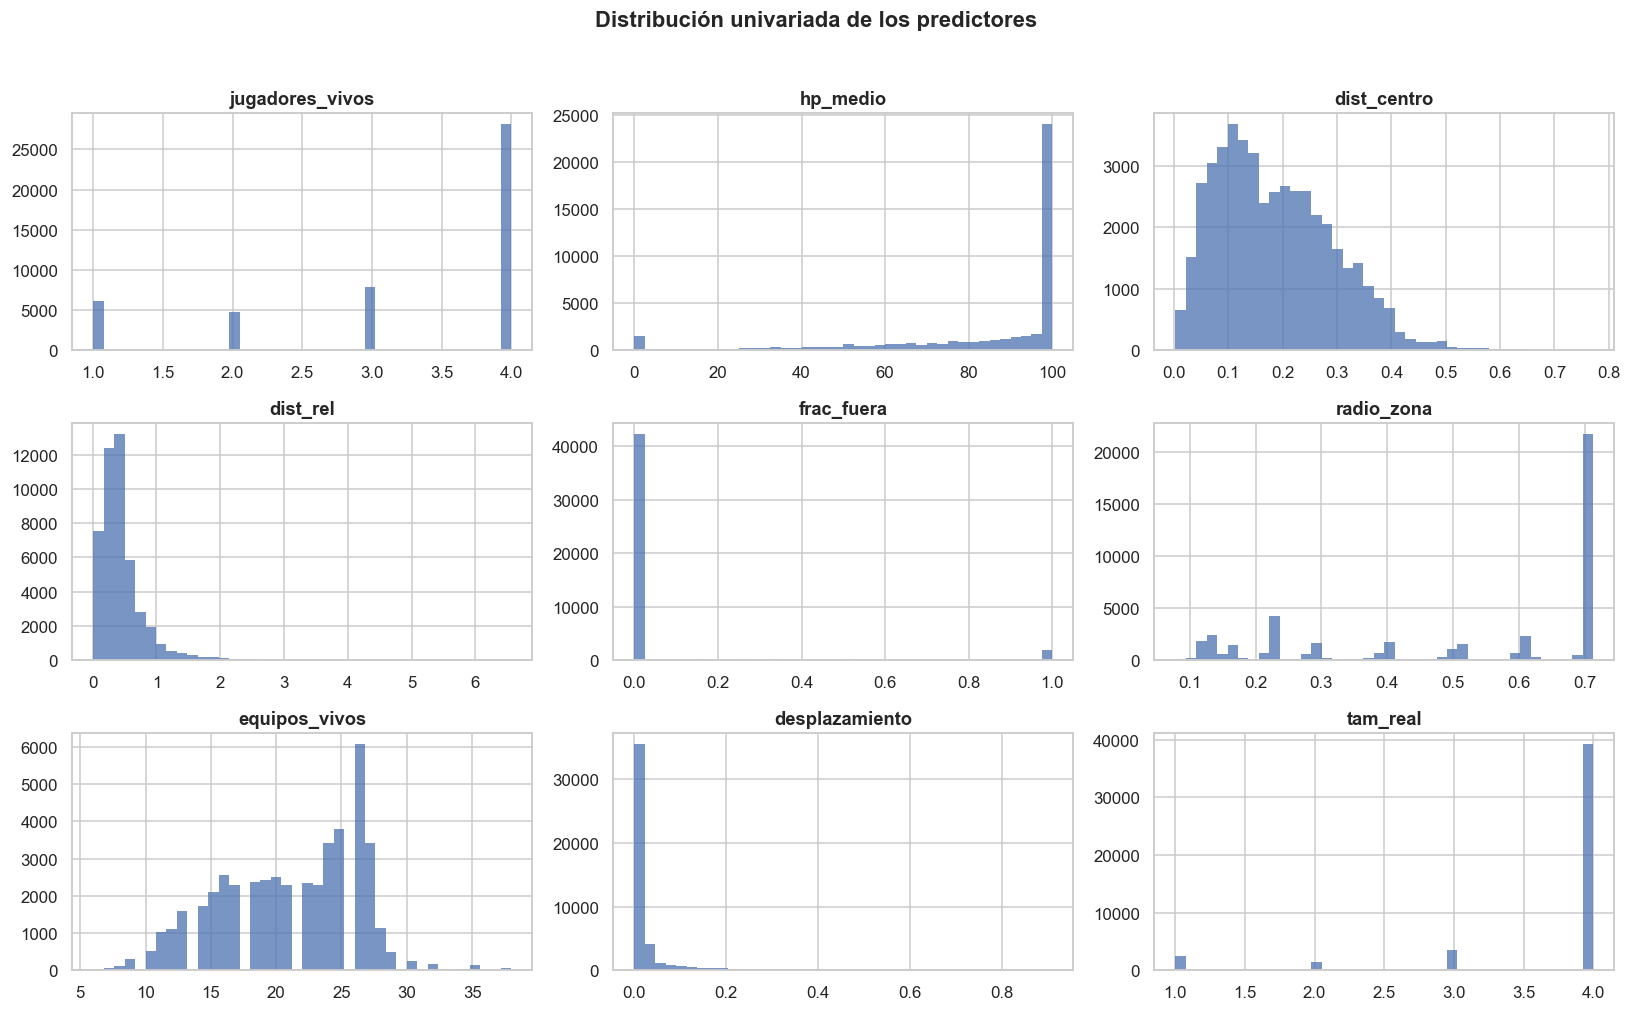

,count,mean,std,min,25%,50%,75%,max
jugadores_vivos,46886.0,3.236,1.083,1.000,3.000,4.000,4.000,4.000
hp_medio,46886.0,82.662,26.436,0.000,73.450,98.291,100.000,100.000
dist_centro,46817.0,0.186,0.107,0.002,0.101,0.171,0.259,0.772
dist_rel,46817.0,0.459,0.392,0.009,0.229,0.374,0.539,6.565
frac_fuera,46886.0,0.065,0.225,0.000,0.000,0.000,0.000,1.000
radio_zona,46817.0,0.506,0.231,0.078,0.235,0.616,0.713,0.713
equipos_vivos,46817.0,20.955,5.297,6.000,17.000,22.000,26.000,38.000
desplazamiento,46886.0,0.040,0.091,0.000,0.003,0.008,0.022,0.911
tam_real,46886.0,3.696,0.776,1.000,4.000,4.000,4.000,4.000


In [7]:
# Conjunto de predictores. fase_zona se excluye deliberadamente: es una
# discretización de radio_zona, de modo que incluir ambas sería redundante.
# Se emplea como eje del análisis, no como variable más.
num = ["jugadores_vivos", "hp_medio", "dist_centro", "dist_rel",
       "frac_fuera", "radio_zona", "equipos_vivos", "desplazamiento", "tam_real"]

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for ax, c in zip(axes.ravel(), num):
    sns.histplot(agg[c], bins=40, ax=ax, color="#4c72b0", edgecolor="none")
    ax.set(title=c, xlabel="", ylabel="")
plt.suptitle("Distribución univariada de los predictores", y=1.02, fontweight="bold")
plt.tight_layout(); plt.show()

display(agg[num].describe().T.round(3))

### 5.3 Geografía de las bajas

La distribución espacial de las eliminaciones revela si el mapa tiene zonas de riesgo diferenciado, lo cual justificaría incorporar la posición absoluta como predictor y no solo la posición relativa al círculo.

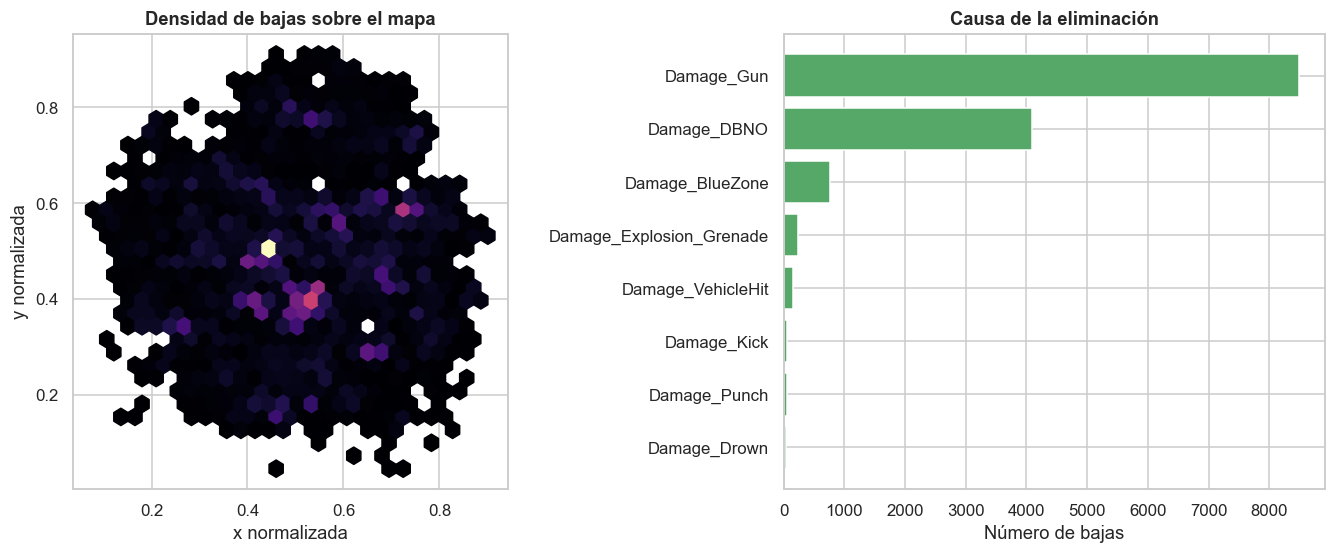

In [8]:
m = muertes.dropna(subset=["victim_x_norm", "victim_y_norm"])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))

axes[0].hexbin(m.victim_x_norm, m.victim_y_norm, gridsize=28,
               cmap="magma", mincnt=1)
axes[0].set(title="Densidad de bajas sobre el mapa",
            xlabel="x normalizada", ylabel="y normalizada")
axes[0].set_aspect("equal")

cat = muertes.damage_category.value_counts().head(8)
axes[1].barh(cat.index.astype(str), cat.values, color="#55a868")
axes[1].set(title="Causa de la eliminación", xlabel="Número de bajas")
axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

### 5.4 Relación entre conducta y desenlace

Esta sección determina si las variables construidas separan a los escuadrones
que llegan al cuarto superior de los que no. El eje es la **fase de la zona**,
no el minuto de reloj, por las razones expuestas en 3.3.

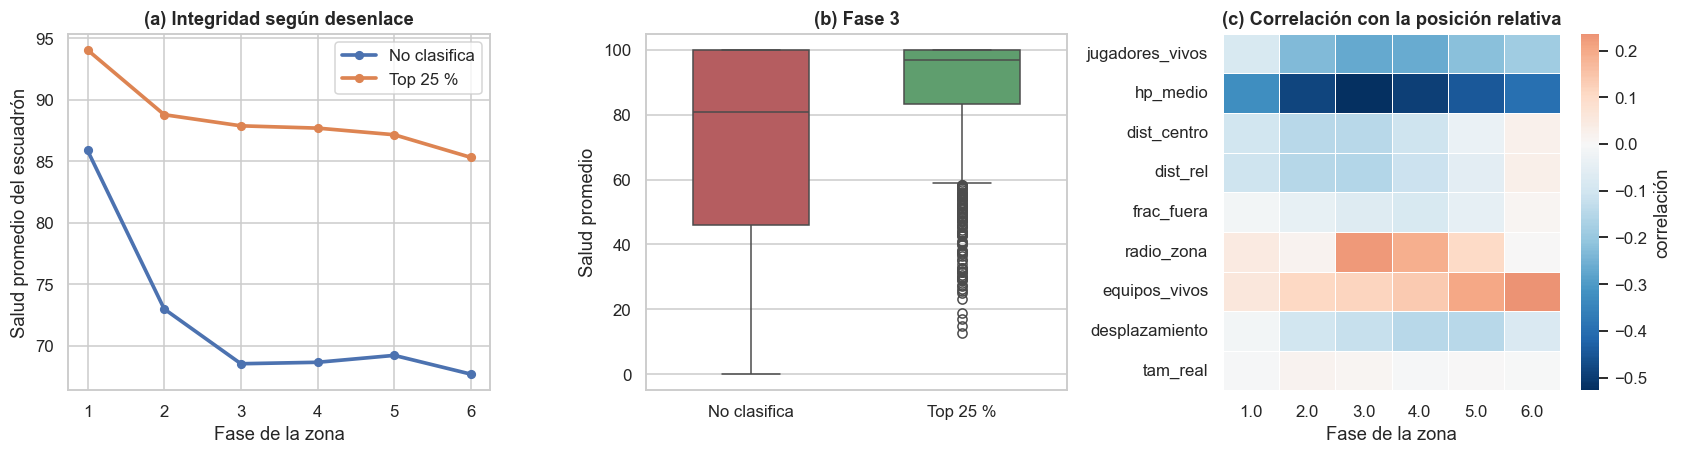

Salud promedio del escuadrón en la fase 3:
         mean     std  count
top25                       
0      68.552  33.972   2007
1      87.884  18.169   1005


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))

# (a) Salud del escuadrón según desenlace, por fase de la zona
tray = agg.groupby(["fase_zona", "top25"]).hp_medio.mean().unstack()
tray.columns = ["No clasifica", "Top 25 %"]
tray.plot(ax=axes[0], lw=2.4, marker="o", ms=5)
axes[0].set(xlabel="Fase de la zona", ylabel="Salud promedio del escuadrón",
            title="(a) Integridad según desenlace")
axes[0].legend(title="")

# (b) Separación en una fase intermedia
f3 = agg[agg.fase_zona == 3]
sns.boxplot(data=f3, x="top25", y="hp_medio", ax=axes[1],
            palette=["#c44e52", "#55a868"], width=.55)
axes[1].set(xticklabels=["No clasifica", "Top 25 %"], xlabel="",
            ylabel="Salud promedio", title="(b) Fase 3")

# (c) Correlación de cada predictor con la posición final, por fase
cors = (agg.dropna(subset=["fase_zona"])
           .groupby("fase_zona")
           .apply(lambda g: g[num].corrwith(g.pct_rank)))
sns.heatmap(cors.T, cmap="RdBu_r", center=0, ax=axes[2],
            cbar_kws={"label": "correlación"}, linewidths=.4)
axes[2].set(xlabel="Fase de la zona", ylabel="",
            title="(c) Correlación con la posición relativa")

plt.tight_layout(); plt.show()

print("Salud promedio del escuadrón en la fase 3:")
print(f3.groupby("top25").hp_medio.agg(["mean", "std", "count"]).round(3))

### 5.5 Multicolinealidad

El temario exige evaluar la multicolinealidad antes de modelar. Se calcula el factor de inflación de varianza regresando cada predictor contra el resto: valores superiores a diez indican redundancia que compromete la interpretación de los coeficientes en modelos lineales.

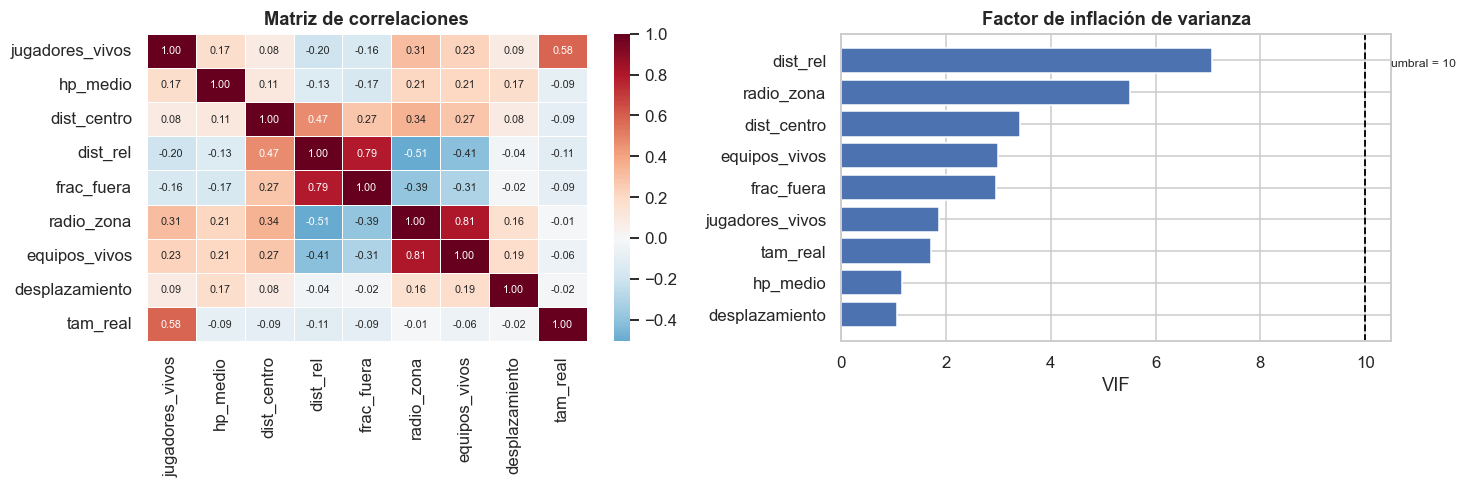

dist_rel           7.08
radio_zona         5.52
dist_centro        3.42
equipos_vivos      2.99
frac_fuera         2.95
jugadores_vivos    1.86
tam_real           1.71
hp_medio           1.15
desplazamiento     1.06


In [10]:
from sklearn.linear_model import LinearRegression

def vif(X: pd.DataFrame) -> pd.Series:
    """Factor de inflación de varianza: 1 / (1 - R²) de cada variable
    regresada contra todas las demás."""
    out = {}
    for c in X.columns:
        r2 = LinearRegression().fit(X.drop(columns=c), X[c]).score(
             X.drop(columns=c), X[c])
        out[c] = 1 / (1 - r2) if r2 < 0.9999 else np.inf
    return pd.Series(out).sort_values(ascending=False)

X = agg[num].dropna()
tabla_vif = vif(X)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

sns.heatmap(X.corr(), cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, ax=axes[0], linewidths=.4)
axes[0].set_title("Matriz de correlaciones")

colores = ["#c44e52" if v > 10 else "#4c72b0" for v in tabla_vif.values]
axes[1].barh(tabla_vif.index, tabla_vif.values, color=colores)
axes[1].axvline(10, ls="--", c="black", lw=1.2)
axes[1].annotate("umbral = 10", (10.5, 0.2), fontsize=8)
axes[1].set(title="Factor de inflación de varianza", xlabel="VIF")
axes[1].invert_yaxis()

plt.tight_layout(); plt.show()
print(tabla_vif.round(2).to_string())

**Hallazgo.** Ningún predictor supera el umbral convencional de diez. El valor
más alto corresponde a `dist_rel`, lo que era previsible: se construye a partir
de `dist_centro` y `radio_zona`, ambas presentes en el conjunto.

Este resultado tiene una consecuencia práctica favorable. No es necesario
descartar variables por redundancia, de modo que los modelos lineales pueden
utilizar el conjunto completo sin comprometer la interpretación de sus
coeficientes. La única correlación notable, entre `radio_zona` y
`equipos_vivos`, refleja que ambas son función del avance de la partida, pero se
mantiene en un nivel que no impide el ajuste.

### 5.6 Reducción de dimensionalidad

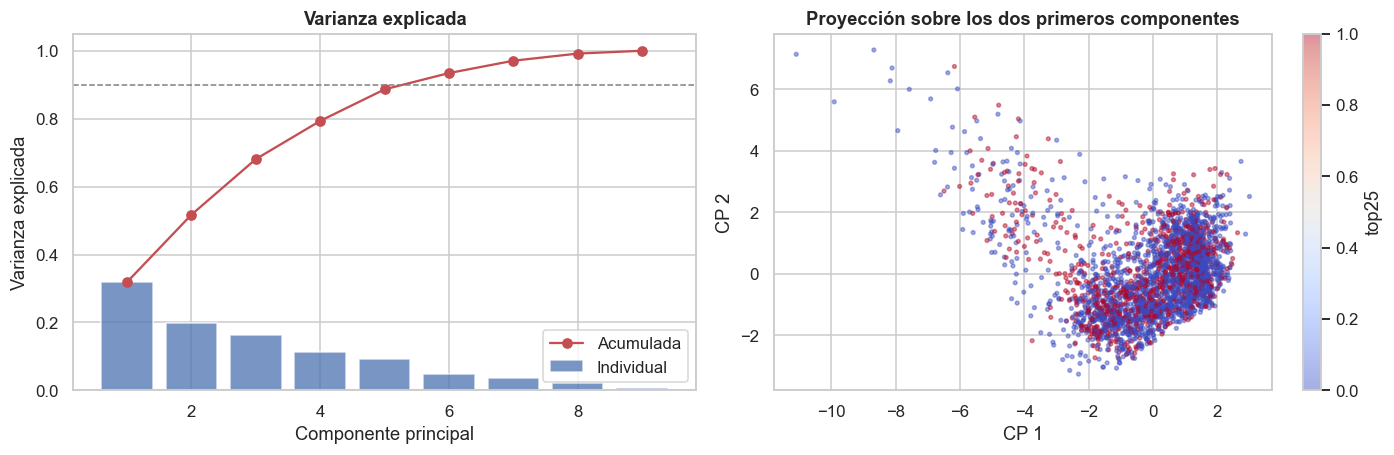

Componentes necesarios para explicar el 90% de la varianza: 6 de 9
Varianza acumulada: [0.319 0.517 0.681 0.793 0.886 0.934 0.971 0.992 1.   ]

Cargas de los tres primeros componentes:


,CP1,CP2,CP3
jugadores_vivos,0.281,0.003,0.635
hp_medio,0.212,0.188,-0.062
dist_centro,0.003,0.657,0.132
dist_rel,-0.465,0.387,0.181
frac_fuera,-0.424,0.341,0.177
radio_zona,0.494,0.281,-0.062
equipos_vivos,0.455,0.302,-0.115
desplazamiento,0.133,0.221,0.004
tam_real,0.108,-0.222,0.703


In [11]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Z    = StandardScaler().fit_transform(X)
pca  = PCA().fit(Z)
acum = np.cumsum(pca.explained_variance_ratio_)
k90  = int(np.argmax(acum >= .90) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

axes[0].bar(range(1, len(acum) + 1), pca.explained_variance_ratio_,
            color="#4c72b0", alpha=.75, label="Individual")
axes[0].plot(range(1, len(acum) + 1), acum, "o-", color="#c44e52",
             label="Acumulada")
axes[0].axhline(.90, ls="--", c="gray", lw=1)
axes[0].set(xlabel="Componente principal", ylabel="Varianza explicada",
            title="Varianza explicada")
axes[0].legend()

Y = pca.transform(Z)[:, :2]
idx = np.random.choice(len(Y), min(3000, len(Y)), replace=False)
sc = axes[1].scatter(Y[idx, 0], Y[idx, 1], c=X.index.map(agg.top25)[idx],
                     cmap="coolwarm", s=6, alpha=.45)
axes[1].set(xlabel="CP 1", ylabel="CP 2",
            title="Proyección sobre los dos primeros componentes")
plt.colorbar(sc, ax=axes[1], label="top25")

plt.tight_layout(); plt.show()

print(f"Componentes necesarios para explicar el 90% de la varianza: {k90} de {len(num)}")
print("Varianza acumulada:", np.round(acum, 3))

cargas = pd.DataFrame(pca.components_[:3].T, index=num,
                      columns=["CP1", "CP2", "CP3"]).round(3)
print("\nCargas de los tres primeros componentes:")
display(cargas)

### 5.7 Poder predictivo individual

Antes de ajustar cualquier modelo conviene medir cuánta información aporta cada variable por separado. Se usa la información mutua, que a diferencia de la correlación detecta relaciones no lineales.

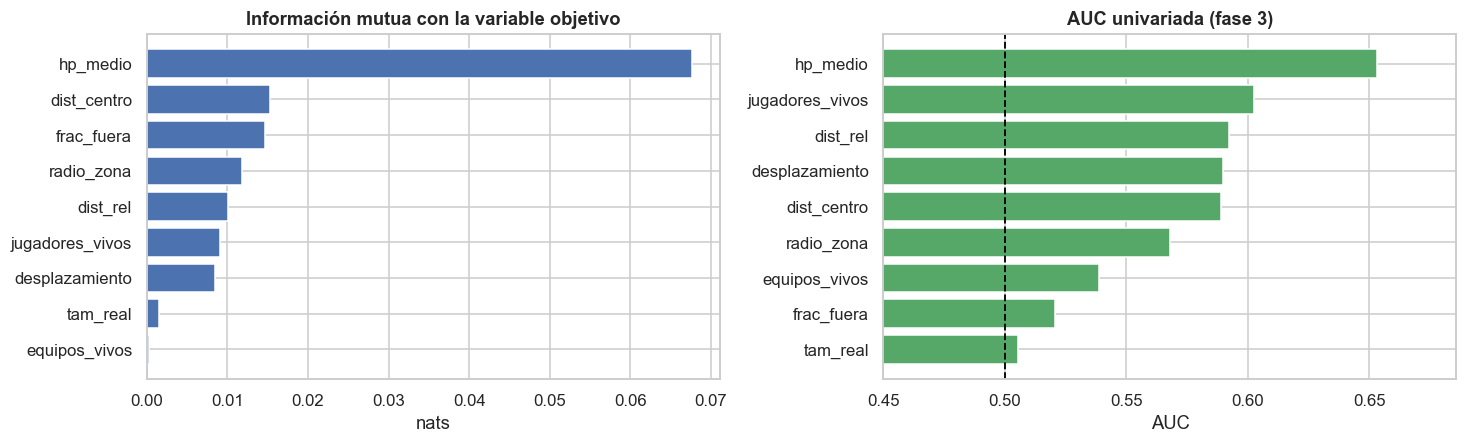

hp_medio           0.653
jugadores_vivos    0.602
dist_rel           0.592
desplazamiento     0.590
dist_centro        0.589
radio_zona         0.568
equipos_vivos      0.539
frac_fuera         0.521
tam_real           0.505


In [12]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score

# Se evalúa en una fase intermedia, no en un minuto de reloj
v = agg[agg.fase_zona == 3].dropna(subset=num)
mi = pd.Series(mutual_info_classif(v[num], v.top25, random_state=SEMILLA),
               index=num).sort_values()

# AUC univariada: qué tan bien separa cada variable por sí sola
auc = {}
for c in num:
    a = roc_auc_score(v.top25, v[c])
    auc[c] = max(a, 1 - a)          # se ignora el sentido de la relación
auc = pd.Series(auc).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
axes[0].barh(mi.index, mi.values, color="#4c72b0")
axes[0].set(title="Información mutua con la variable objetivo", xlabel="nats")
axes[1].barh(auc.index, auc.values, color="#55a868")
axes[1].axvline(.5, ls="--", c="black", lw=1.2)
axes[1].set(title="AUC univariada (fase 3)", xlabel="AUC", xlim=(.45, None))
plt.tight_layout(); plt.show()

print(auc.sort_values(ascending=False).round(3).to_string())

### 5.8 Separabilidad a lo largo de la partida

El indicador central del proyecto es la cantidad de información sobre el
desenlace disponible en cada momento. Se mide como el área bajo la curva que
alcanza el mejor predictor individual, evaluado fase por fase.

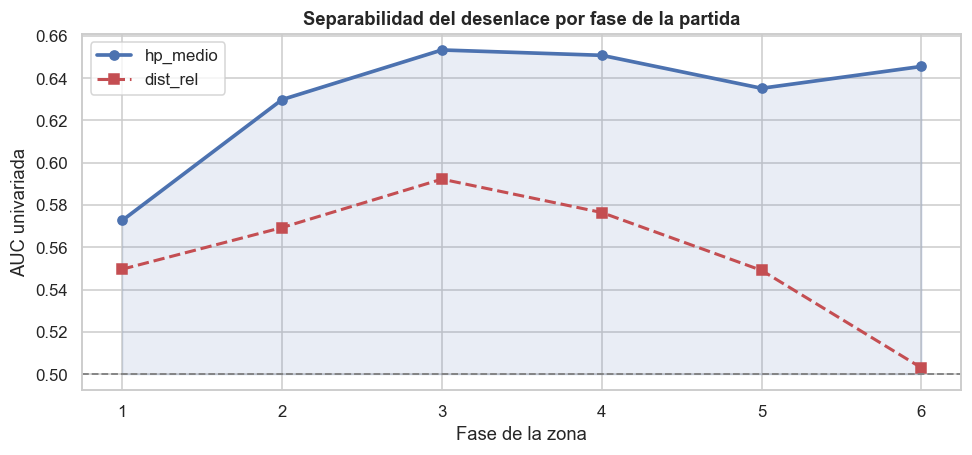

Mejor predictor (hp_medio):


,fase_zona,auc,n,tasa_base
0,1.0,0.573,25037,0.274
1,2.0,0.630,3851,0.320
2,3.0,0.653,3012,0.334
3,4.0,0.651,2840,0.356
4,5.0,0.635,7223,0.406
5,6.0,0.646,4854,0.473


In [13]:
from sklearn.metrics import roc_auc_score

def auc_por(eje, var):
    """AUC univariada de `var` sobre top25, calculada dentro de cada nivel de `eje`."""
    filas = []
    for k, g in agg.groupby(eje):
        g = g.dropna(subset=[var])
        if g.top25.nunique() < 2 or len(g) < 200:
            continue
        a = roc_auc_score(g.top25, g[var])
        filas.append({eje: k, "auc": max(a, 1 - a), "n": len(g),
                      "tasa_base": round(g.top25.mean(), 3)})
    return pd.DataFrame(filas)

sep_hp   = auc_por("fase_zona", "hp_medio")
sep_dist = auc_por("fase_zona", "dist_rel")

plt.figure(figsize=(9, 4.3))
plt.plot(sep_hp.fase_zona,   sep_hp.auc,   "o-", lw=2.4,
         color="#4c72b0", label="hp_medio")
plt.plot(sep_dist.fase_zona, sep_dist.auc, "s--", lw=2.0,
         color="#c44e52", label="dist_rel")
plt.axhline(.5, ls="--", c="gray", lw=1.2)
plt.fill_between(sep_hp.fase_zona, .5, sep_hp.auc, alpha=.12, color="#4c72b0")
plt.xlabel("Fase de la zona"); plt.ylabel("AUC univariada")
plt.title("Separabilidad del desenlace por fase de la partida")
plt.legend(); plt.tight_layout(); plt.show()

print("Mejor predictor (hp_medio):"); display(sep_hp.round(3))

### 5.9 Refutación de la hipótesis inicial

El diseño del proyecto partió de una hipótesis explícita: que el posicionamiento
relativo a la zona segura, recogido en `dist_rel`, sería el principal
determinante del desenlace. La intuición era razonable —quedar fuera del círculo
ocasiona daño continuo— y motivó la construcción de esa variable como pieza
central de la ingeniería de características.

El análisis exploratorio no la sostiene. Esta sección documenta la refutación y
el replanteamiento que se derivó de ella.

In [14]:
# --- (1) dist_rel confunde posicionamiento con avance de la partida ----------
diag = agg.groupby("fase_zona").agg(n=("team_id", "size"),
                                    tasa_top25=("top25", "mean"),
                                    dist_rel=("dist_rel", "mean")).round(3)
print("Comportamiento de dist_rel a lo largo de las fases:")
display(diag)

# --- (2) ¿Recupera poder predictivo al controlar por fase? -------------------
print("\nAUC de dist_rel DENTRO de cada fase (comparación justa):")
display(sep_dist.round(3))

# --- (3) La fase por sí sola, como referencia -------------------------------
gf = agg.dropna(subset=["fase_zona"])
a  = roc_auc_score(gf.top25, gf.fase_zona)
print(f"\nAUC de fase_zona por sí sola: {max(a, 1-a):.3f}")
print("(Refleja sobre todo el sesgo de supervivencia, no capacidad predictiva)")

# --- (4) Qué mata realmente en el juego --------------------------------------
causas = muertes.damage_category.value_counts(normalize=True).head(5).round(4)
print("\nCausa de las eliminaciones (proporción):")
display(causas)

Comportamiento de dist_rel a lo largo de las fases:


,n,tasa_top25,dist_rel
fase_zona,,,
1.0,25037,0.274,0.308
2.0,3851,0.320,0.355
3.0,3012,0.334,0.433
4.0,2840,0.356,0.604
5.0,7223,0.406,0.721
6.0,4854,0.473,0.858



AUC de dist_rel DENTRO de cada fase (comparación justa):


,fase_zona,auc,n,tasa_base
0,1.0,0.550,25037,0.274
1,2.0,0.569,3851,0.320
2,3.0,0.592,3012,0.334
3,4.0,0.576,2840,0.356
4,5.0,0.549,7223,0.406
5,6.0,0.503,4854,0.473



AUC de fase_zona por sí sola: 0.580
(Refleja sobre todo el sesgo de supervivencia, no capacidad predictiva)

Causa de las eliminaciones (proporción):


damage_category
Damage_Gun                  0.6034
Damage_DBNO                 0.2909
Damage_BlueZone             0.0541
Damage_Explosion_Grenade    0.0171
Damage_VehicleHit           0.0112
Name: proportion, dtype: float64

**Diagnóstico.** La distancia relativa crece de forma sostenida conforme el
círculo se contrae, lo que era esperable: a menor radio, mayor distancia
relativa para una misma separación absoluta. Como las fases avanzadas solo las
alcanzan los escuadrones que sobrevivieron, la variable termina midiendo, en
buena parte, cuán lejos llegó el equipo y no cuán bien se posicionó. Es un caso
de confusión estadística de manual, y explica que la asociación aparente aparezca
incluso con el signo invertido.

Al controlar por fase, que es la comparación justa, `dist_rel` mejora pero no lo
bastante para sostener un planteamiento.

**Por qué falla la intuición.** La distribución de causas de eliminación lo
aclara: la zona de gas produce una fracción pequeña de las bajas, mientras que
la abrumadora mayoría procede de armas de fuego. En una partida de esta duración
no mata el círculo, matan los adversarios. El posicionamiento importa como
mediador —determina con quién te encuentras— pero no como causa directa.

**Replanteamiento.** Los predictores efectivos resultan ser los que describen la
condición del escuadrón: salud promedio, integrantes con vida y movilidad. El
proyecto se reformula en consecuencia:

> Estimación del estado competitivo de un escuadrón a partir de su **integridad
> y condición**, condicionada a la fase de la partida.

`dist_rel` se conserva en el conjunto de predictores por dos motivos. Primero,
porque su interacción con la salud puede resultar informativa aunque su efecto
aislado no lo sea: un escuadrón herido y fuera de la zona no se encuentra en la
misma situación que uno herido y protegido, y los modelos de ensamble y las
redes neuronales pueden capturar esa interacción. Segundo, porque documentar una
variable que la teoría sugería y los datos desmienten forma parte del
resultado.

## 6. Cierre del análisis exploratorio

**Sobre los datos.** La interfaz oficial entrega información suficiente y de
buena calidad. Las 150 partidas presentan etiquetas íntegras: todas tienen
exactamente un escuadrón ganador y las posiciones finales forman secuencias
completas. Los valores ausentes son marginales y de origen estructural, salvo
`desplazamiento`, cuya ausencia en la primera ventana de cada escuadrón responde
a su propia definición y admite imputación justificada.

**Sobre la señal.** La integridad del escuadrón —salud promedio, integrantes con
vida— discrimina el desenlace con claridad, mientras que el posicionamiento
relativo a la zona no lo hace. Esta conclusión contradice la hipótesis con la que
se diseñó la ingeniería de características, y su documentación se presenta en la
sección 5.9.

**Sobre la estructura temporal.** El minuto de reloj no es comparable entre
partidas, porque cada una entra en las fases del círculo en momentos distintos.
El eje temporal correcto es la fase de la zona, y todo el análisis se organiza
sobre ella.

**Sobre el sesgo de supervivencia.** La tasa de escuadrones destinados al cuarto
superior crece de forma monótona entre los supervivientes, hasta más que
duplicarse hacia el final del horizonte analizado. Es una propiedad del
fenómeno, no un defecto del muestreo, y reformula la pregunta del sistema en
términos condicionales.

**Sobre la estructura de dependencia.** Ningún predictor presenta
multicolinealidad problemática. No es necesario descartar variables y los
modelos lineales pueden emplear el conjunto completo.

### Implicaciones para la siguiente etapa

1. Emplear `top25` como variable objetivo, nunca la posición absoluta.
2. Construir las secuencias sobre la fase de la zona, no sobre el minuto.
3. Ponderar las clases durante el entrenamiento y evaluar con área bajo la curva
   y puntaje de Brier.
4. Particionar por fecha de partida, nunca de forma aleatoria: las ventanas de
   una misma partida están correlacionadas entre sí.
5. Evaluar el desempeño **dentro de cada fase**, para que la tasa base creciente
   no se confunda con capacidad predictiva del modelo.

In [15]:
# Persistencia de la tabla analítica para la siguiente etapa.
# Se intenta Parquet por eficiencia y preservación de tipos; si el entorno no
# cuenta con un motor disponible se recurre a CSV comprimido, de modo que el
# notebook nunca interrumpe su ejecución por una dependencia opcional.
try:
    destino = BASE / "tabla_analitica.parquet"
    agg.to_parquet(destino, index=False)
except ImportError:
    destino = BASE / "tabla_analitica.csv.gz"
    agg.to_csv(destino, index=False, compression="gzip")

print(f"Guardado: {destino} — {agg.shape[0]:,} filas × {agg.shape[1]} columnas")

Guardado: datos\tabla_analitica.parquet — 46,886 filas × 20 columnas


---

# Segunda parte — Modelación

El análisis exploratorio queda cerrado. A partir de aquí se construyen los
modelos sobre la tabla analítica ya validada.

## 7. Partición de los datos

In [16]:
# --- Constantes de la etapa de modelado --------------------------------------
from pathlib import Path
MODELOS = Path("modelos"); MODELOS.mkdir(exist_ok=True)

PREDICTORES = ["jugadores_vivos", "hp_medio", "hp_minimo", "dist_centro",
               "dist_rel", "frac_fuera", "radio_zona", "equipos_vivos",
               "desplazamiento", "tam_real", "fase_zona"]
OBJETIVO  = "top25"
APERTURA  = 5      # ventanas que definen el perfil de estilo de juego
PASOS     = 15     # longitud de secuencia para la red recurrente

# La tabla ya está en memoria si el notebook se ejecutó desde el inicio.
# Si se reinició el núcleo, se recupera del archivo guardado en la sección 6.
if "agg" not in globals():
    for nombre in ["tabla_analitica.parquet", "tabla_analitica.csv.gz"]:
        ruta = BASE / nombre
        if ruta.exists():
            agg = pd.read_parquet(ruta) if ruta.suffix == ".parquet" else pd.read_csv(ruta)
            print(f"Tabla recuperada de {ruta}")
            break
    else:
        raise FileNotFoundError("Ejecuta primero las secciones 1 a 6.")

d = agg.dropna(subset=[OBJETIVO, "fase_zona"]).copy()
d["desplazamiento"] = d.desplazamiento.fillna(0)

print(f"Observaciones : {len(d):,}")
print(f"Partidas      : {d.match_id.nunique():,}")
print(f"Escuadrones   : {d.groupby(['match_id','team_id']).ngroups:,}")
print(f"Tasa de {OBJETIVO} : "
      f"{d.drop_duplicates(['match_id','team_id'])[OBJETIVO].mean():.1%}")

Observaciones : 46,817
Partidas      : 150
Escuadrones   : 3,862
Tasa de top25 : 26.5%


In [17]:
from sklearn.model_selection import GroupShuffleSplit

def particion(df, prop_prueba=0.30, semilla=SEMILLA):
    """Separa el conjunto agrupando por partida: ninguna partida se reparte."""
    gss = GroupShuffleSplit(n_splits=1, test_size=prop_prueba, random_state=semilla)
    i_a, i_b = next(gss.split(df, groups=df.match_id))
    return df.iloc[i_a].copy(), df.iloc[i_b].copy()

tr_val, test = particion(d, 0.30)
train, val   = particion(tr_val, 0.20)

resumen = []
for nombre, parte in [("Entrenamiento", train), ("Validación", val), ("Prueba", test)]:
    resumen.append({"Conjunto": nombre, "Filas": len(parte),
                    "Partidas": parte.match_id.nunique(),
                    "Escuadrones": parte.groupby(["match_id","team_id"]).ngroups,
                    "Tasa objetivo": round(parte[OBJETIVO].mean(), 3)})
display(pd.DataFrame(resumen))

# Verificación explícita de ausencia de fuga
for a, b, etiqueta in [(train, val, "entrenamiento/validación"),
                       (train, test, "entrenamiento/prueba"),
                       (val, test, "validación/prueba")]:
    solape = set(a.match_id) & set(b.match_id)
    assert not solape, f"FUGA en {etiqueta}: {len(solape)} partidas compartidas"
print("Verificado: ninguna partida aparece en dos conjuntos.")

,Conjunto,Filas,Partidas,Escuadrones,Tasa objetivo
0,Entrenamiento,25970,84,2144,0.329
1,Validación,6756,21,557,0.324
2,Prueba,14091,45,1161,0.327


Verificado: ninguna partida aparece en dos conjuntos.


## 8. Modelación supervisada de referencia

Se comparan cuatro familias sobre el mismo conjunto de predictores. Todas se
encapsulan en una tubería que imputa valores ausentes y, cuando corresponde,
estandariza: así la transformación se ajusta **solo con entrenamiento** y se
aplica sin contaminar validación ni prueba.

El desbalance se atiende mediante ponderación de clases, no mediante remuestreo,
para no alterar la distribución real de la que dependen las probabilidades
calibradas.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_auc_score, brier_score_loss,
                             average_precision_score, roc_curve)

Xtr, ytr = train[PREDICTORES], train[OBJETIVO]
Xva, yva = val[PREDICTORES],   val[OBJETIVO]
Xte, yte = test[PREDICTORES],  test[OBJETIVO]

def tuberia(modelo, escalar=True):
    """Imputación → (estandarización) → modelo, ajustado solo con entrenamiento."""
    pasos = [("imputar", SimpleImputer(strategy="median"))]
    if escalar:
        pasos.append(("escalar", StandardScaler()))
    pasos.append(("modelo", modelo))
    return Pipeline(pasos)

modelos = {
    "Regresión logística": tuberia(
        LogisticRegression(max_iter=2000, class_weight="balanced")),

    "Bosque aleatorio": tuberia(
        RandomForestClassifier(n_estimators=400, min_samples_leaf=20,
                               class_weight="balanced", n_jobs=-1,
                               random_state=SEMILLA), escalar=False),

    "Impulso gradiente": tuberia(
        HistGradientBoostingClassifier(max_iter=400, learning_rate=0.06,
                                       max_leaf_nodes=31, l2_regularization=1.0,
                                       random_state=SEMILLA), escalar=False),

    # Red profunda alimentada hacia adelante (punto 4.2 del temario)
    "Red densa": tuberia(
        MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu",
                      alpha=1e-3, max_iter=500, early_stopping=True,
                      n_iter_no_change=15, random_state=SEMILLA)),
}

def evaluar(modelo, X, y):
    """AUC, Brier y precisión promedio sobre un conjunto."""
    p = modelo.predict_proba(X)[:, 1]
    return {"AUC": roc_auc_score(y, p),
            "Brier": brier_score_loss(y, p),
            "AP": average_precision_score(y, p)}

ajustados, filas = {}, []
for nombre, modelo in modelos.items():
    modelo.fit(Xtr, ytr)
    ajustados[nombre] = modelo
    r = evaluar(modelo, Xva, yva); r["Modelo"] = nombre
    filas.append(r)
    print(f"  {nombre:22s} AUC {r['AUC']:.3f}   Brier {r['Brier']:.3f}")

comparativa = pd.DataFrame(filas).set_index("Modelo").round(4)
print("\nDesempeño en validación:")
display(comparativa)

  Regresión logística    AUC 0.685   Brier 0.223
  Bosque aleatorio       AUC 0.711   Brier 0.210
  Impulso gradiente      AUC 0.711   Brier 0.192
  Red densa              AUC 0.706   Brier 0.193

Desempeño en validación:


,AUC,Brier,AP
Modelo,,,
Regresión logística,0.6852,0.2227,0.497
Bosque aleatorio,0.7113,0.2102,0.531
Impulso gradiente,0.7109,0.1916,0.535
Red densa,0.7058,0.1934,0.519


### 8.1 Curvas ROC y calibración

El AUC mide el ordenamiento; el puntaje de Brier mide si las probabilidades son creíbles. Un modelo puede ordenar bien y estar mal calibrado, y para esta aplicación la calibración importa: la cifra se le muestra al usuario como probabilidad.

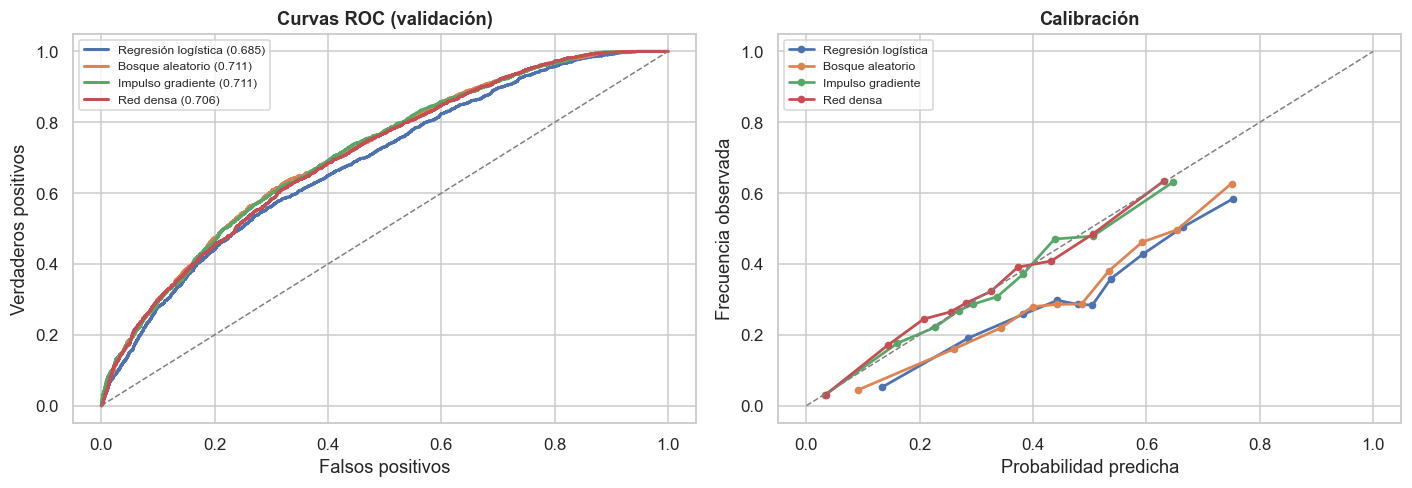

In [19]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

for nombre, modelo in ajustados.items():
    p = modelo.predict_proba(Xva)[:, 1]
    fpr, tpr, _ = roc_curve(yva, p)
    axes[0].plot(fpr, tpr, lw=2,
                 label=f"{nombre} ({roc_auc_score(yva, p):.3f})")
    frac, media = calibration_curve(yva, p, n_bins=10, strategy="quantile")
    axes[1].plot(media, frac, "o-", lw=1.8, ms=4, label=nombre)

axes[0].plot([0, 1], [0, 1], "--", c="gray", lw=1)
axes[0].set(xlabel="Falsos positivos", ylabel="Verdaderos positivos",
            title="Curvas ROC (validación)")
axes[0].legend(fontsize=8)

axes[1].plot([0, 1], [0, 1], "--", c="gray", lw=1)
axes[1].set(xlabel="Probabilidad predicha", ylabel="Frecuencia observada",
            title="Calibración")
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

### 8.2 Evaluación dentro de cada fase

Esta es la evaluación que importa. Como la tasa base de escuadrones destinados
al cuarto superior crece con la fase por efecto del sesgo de supervivencia, una
métrica global mezcla problemas de dificultad distinta.

Se reporta además la tasa base de cada fase, para que el AUC se lea contra la
dificultad real de esa etapa.

Mejor modelo en validación: Bosque aleatorio



,Fase,n,Tasa base,AUC,Brier
0,1,3600,0.273,0.637,0.208
1,2,575,0.313,0.671,0.224
2,3,442,0.326,0.731,0.209
3,4,418,0.344,0.730,0.211
4,5,1040,0.401,0.750,0.207
5,6,681,0.471,0.759,0.214


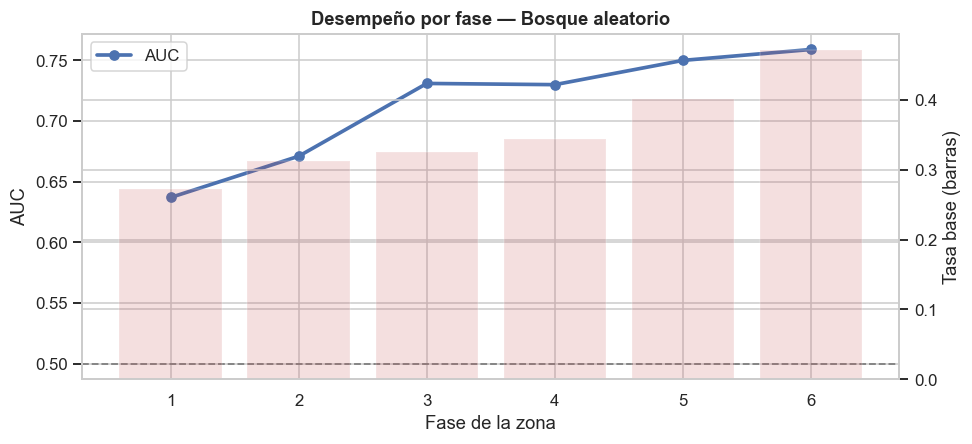

In [20]:
mejor_nombre = comparativa.AUC.idxmax()
mejor = ajustados[mejor_nombre]
print(f"Mejor modelo en validación: {mejor_nombre}\n")

val_ev = val.copy()
val_ev["p"] = mejor.predict_proba(Xva)[:, 1]

filas = []
for fase, g in val_ev.groupby("fase_zona"):
    if g[OBJETIVO].nunique() < 2 or len(g) < 100:
        continue
    filas.append({"Fase": int(fase), "n": len(g),
                  "Tasa base": round(g[OBJETIVO].mean(), 3),
                  "AUC": roc_auc_score(g[OBJETIVO], g.p),
                  "Brier": brier_score_loss(g[OBJETIVO], g.p)})
por_fase = pd.DataFrame(filas).round(3)
display(por_fase)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(por_fase.Fase, por_fase.AUC, "o-", lw=2.4, color="#4c72b0", label="AUC")
ax.axhline(.5, ls="--", c="gray", lw=1.2)
ax.set(xlabel="Fase de la zona", ylabel="AUC", title=f"Desempeño por fase — {mejor_nombre}")
ax2 = ax.twinx()
ax2.bar(por_fase.Fase, por_fase["Tasa base"], alpha=.18, color="#c44e52")
ax2.set_ylabel("Tasa base (barras)")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

### 8.3 Importancia de variables

Se emplea importancia por permutación, que mide la caída de desempeño al desordenar cada variable. A diferencia de la importancia interna de los árboles, no favorece a las variables con muchos valores distintos.

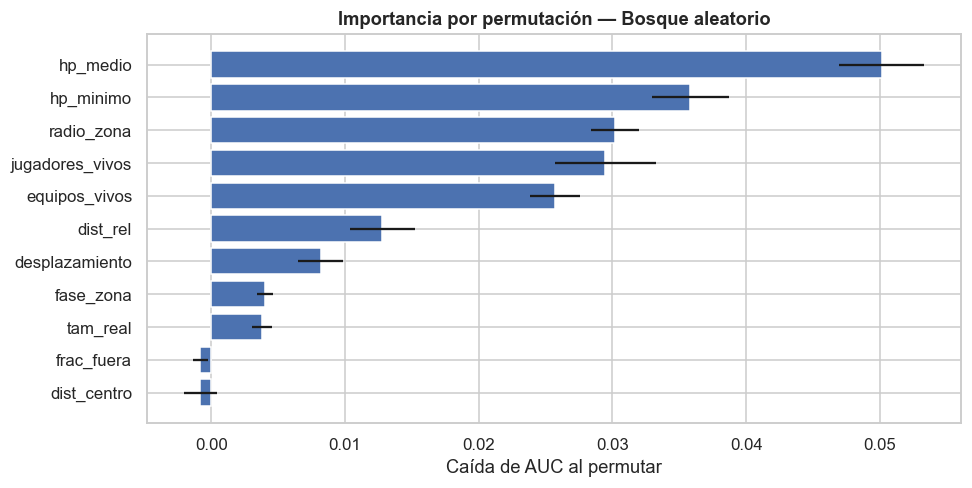

hp_medio           0.0501
hp_minimo          0.0358
radio_zona         0.0302
jugadores_vivos    0.0295
equipos_vivos      0.0257
dist_rel           0.0128
desplazamiento     0.0082
fase_zona          0.0040
tam_real           0.0038
frac_fuera        -0.0008
dist_centro       -0.0008


In [21]:
from sklearn.inspection import permutation_importance

imp = permutation_importance(mejor, Xva, yva, n_repeats=10,
                             random_state=SEMILLA, scoring="roc_auc", n_jobs=-1)
orden = pd.Series(imp.importances_mean, index=PREDICTORES).sort_values()

plt.figure(figsize=(9, 4.6))
plt.barh(orden.index, orden.values,
         xerr=pd.Series(imp.importances_std, index=PREDICTORES)[orden.index],
         color="#4c72b0")
plt.xlabel("Caída de AUC al permutar")
plt.title(f"Importancia por permutación — {mejor_nombre}")
plt.tight_layout(); plt.show()

print(orden.sort_values(ascending=False).round(4).to_string())

## 9. Modelación no supervisada: perfiles de estilo de juego

### Por qué el perfil se calcula solo con la apertura

El perfilamiento describe cómo juega un escuadrón. La tentación es calcularlo
con la partida completa, pero eso introduciría **fuga de información**: el
perfil incorporaría lo ocurrido después del instante en que el modelo lo usa
como predictor.

Se restringe por tanto a las primeras cinco ventanas —la apertura de la
partida—, de modo que esté disponible desde el minuto cinco en adelante. El
modelo supervisado que lo consume se evalúa únicamente a partir de esa
ventana.

In [22]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             adjusted_rand_score)

# Características de apertura, una fila por escuadrón
perfil = (d[d.ventana < APERTURA]
            .groupby(["match_id", "team_id"])
            .agg(hp_apertura=("hp_medio", "mean"),
                 dist_apertura=("dist_rel", "mean"),
                 movilidad=("desplazamiento", "mean"),
                 var_dist=("dist_rel", "std"),
                 var_mov=("desplazamiento", "std"),
                 tam_real=("tam_real", "first"),
                 pct_rank=("pct_rank", "first"))
            .reset_index())

CARACTERISTICAS = ["hp_apertura", "dist_apertura", "movilidad", "var_dist", "var_mov"]

Z = StandardScaler().fit_transform(
        SimpleImputer(strategy="median").fit_transform(perfil[CARACTERISTICAS]))
print(f"Escuadrones para perfilamiento: {Z.shape[0]:,} × {Z.shape[1]} características")

Escuadrones para perfilamiento: 3,862 × 5 características


### 9.1 Comparación de algoritmos

Se comparan los cuatro métodos del temario. Los tres primeros reciben el número de grupos como parámetro; DBSCAN lo infiere del radio de vecindad, por lo que se explora ese radio en su lugar.

,Algoritmo,k,Silueta,Calinski-Harabasz
18,DBSCAN (eps=0.5),2,0.287,87.270
6,K-medias,4,0.272,1358.400
9,K-medias,5,0.262,1290.921
3,K-medias,3,0.261,1396.836
0,K-medias,2,0.252,1341.376
15,K-medias,7,0.239,1153.213
12,K-medias,6,0.229,1210.257
10,Ward,5,0.222,967.526
1,Ward,2,0.218,1024.241
7,Ward,4,0.216,1057.683



Selección: K-medias con k = 4


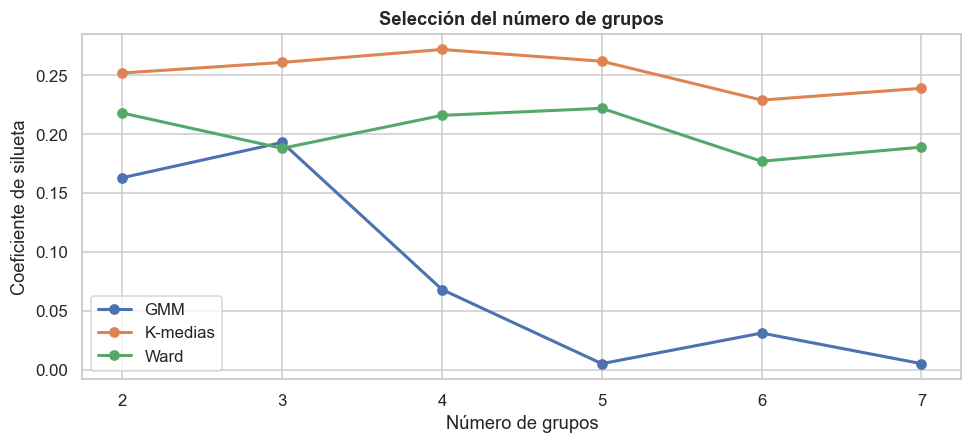

In [23]:
comp = []
for k in range(2, 8):
    for nombre, alg in [("K-medias", KMeans(k, n_init=10, random_state=SEMILLA)),
                        ("Ward",     AgglomerativeClustering(k, linkage="ward")),
                        ("GMM",      GaussianMixture(k, random_state=SEMILLA))]:
        etiquetas = alg.fit_predict(Z)
        comp.append({"Algoritmo": nombre, "k": k,
                     "Silueta": silhouette_score(Z, etiquetas),
                     "Calinski-Harabasz": calinski_harabasz_score(Z, etiquetas)})

# DBSCAN: se explora el radio. Solo se reporta cuando halla dos grupos o más,
# ya que el coeficiente de silueta lo exige.
for eps in [0.5, 0.7, 0.9, 1.1, 1.3]:
    et = DBSCAN(eps=eps, min_samples=25).fit_predict(Z)
    nucleo = et != -1
    if len(set(et[nucleo])) < 2 or nucleo.sum() < 50:
        continue
    comp.append({"Algoritmo": f"DBSCAN (eps={eps})", "k": len(set(et[nucleo])),
                 "Silueta": silhouette_score(Z[nucleo], et[nucleo]),
                 "Calinski-Harabasz": calinski_harabasz_score(Z[nucleo], et[nucleo])})

cdf = pd.DataFrame(comp).round(3)
display(cdf.sort_values("Silueta", ascending=False).head(10))

# El número de grupos se elige entre los algoritmos que lo reciben como
# parámetro; DBSCAN se reporta como contraste pero no define k.
centroide = cdf[cdf.Algoritmo.isin(["K-medias", "Ward", "GMM"])]
k_elegido = int(centroide.loc[centroide.Silueta.idxmax(), "k"])
alg_elegido = centroide.loc[centroide.Silueta.idxmax(), "Algoritmo"]
print(f"\nSelección: {alg_elegido} con k = {k_elegido}")

fig, ax = plt.subplots(figsize=(9, 4.2))
for nombre, g in centroide.groupby("Algoritmo"):
    ax.plot(g.k, g.Silueta, "o-", lw=2, label=nombre)
ax.set(xlabel="Número de grupos", ylabel="Coeficiente de silueta",
       title="Selección del número de grupos")
ax.legend(); plt.tight_layout(); plt.show()

### 9.2 Caracterización de los grupos

Un agrupamiento sin interpretación no es perfilamiento. Se describe cada grupo por su desviación respecto del promedio general y se le asigna un nombre.

,hp_apertura,dist_apertura,movilidad,var_dist,var_mov,pct_rank,n
grupo,,,,,,,
0,95.290,0.404,0.048,0.032,0.086,0.441,1102
1,95.504,0.381,0.115,0.056,0.206,0.441,1002
2,94.658,0.191,0.057,0.082,0.105,0.493,1275
3,66.410,0.282,0.061,0.056,0.119,0.784,483


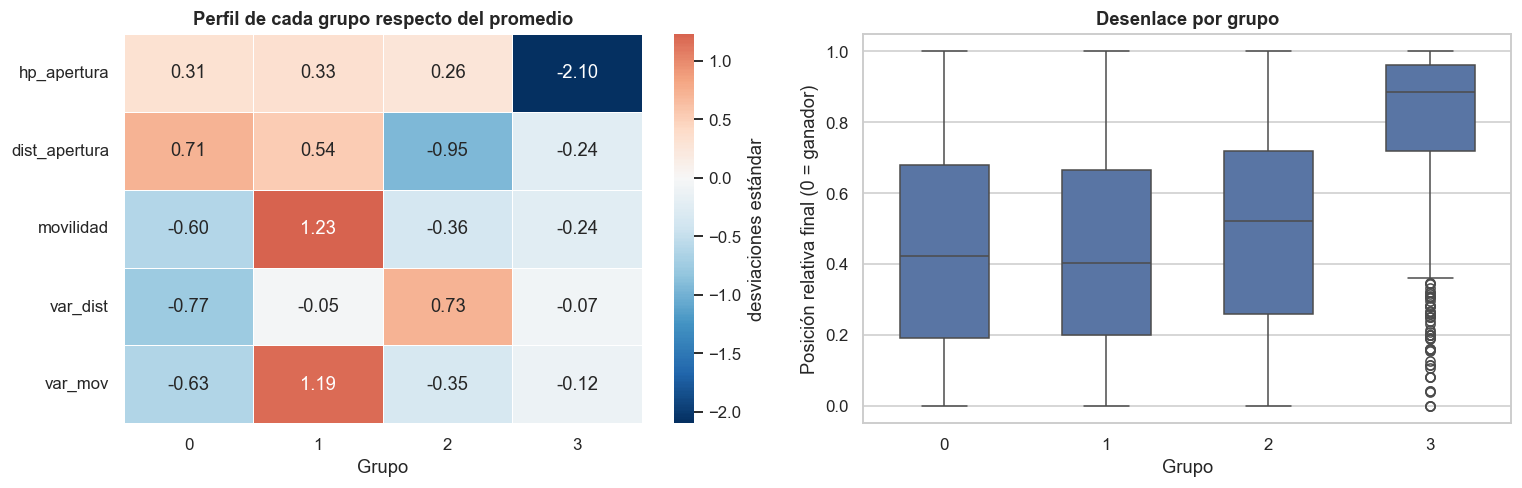


Asigna un nombre a cada grupo a partir del mapa de calor.
Sustituye el diccionario siguiente con los nombres que correspondan:

NOMBRES = {np.int32(0): 'Perfil 0', np.int32(1): 'Perfil 1', np.int32(2): 'Perfil 2', np.int32(3): 'Perfil 3'}


In [24]:
km = KMeans(k_elegido, n_init=10, random_state=SEMILLA).fit(Z)
perfil["grupo"] = km.labels_

resumen_grupos = (perfil.groupby("grupo")[CARACTERISTICAS + ["pct_rank"]]
                        .mean().round(3))
resumen_grupos["n"] = perfil.grupo.value_counts().sort_index()
display(resumen_grupos)

# Desviación estandarizada respecto del promedio general: facilita nombrarlos
desv = ((perfil.groupby("grupo")[CARACTERISTICAS].mean() - perfil[CARACTERISTICAS].mean())
        / perfil[CARACTERISTICAS].std())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
sns.heatmap(desv.T, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            ax=axes[0], linewidths=.4, cbar_kws={"label": "desviaciones estándar"})
axes[0].set(title="Perfil de cada grupo respecto del promedio", xlabel="Grupo")

sns.boxplot(data=perfil, x="grupo", y="pct_rank", ax=axes[1], width=.55)
axes[1].set(xlabel="Grupo", ylabel="Posición relativa final (0 = ganador)",
            title="Desenlace por grupo")
plt.tight_layout(); plt.show()

print("\nAsigna un nombre a cada grupo a partir del mapa de calor.")
print("Sustituye el diccionario siguiente con los nombres que correspondan:\n")
NOMBRES = {g: f"Perfil {g}" for g in sorted(perfil.grupo.unique())}
print("NOMBRES =", NOMBRES)

### 9.3 Estabilidad del agrupamiento

El punto 3.7 del temario pide reportar estabilidad. Se remuestrea el 80 % de los escuadrones, se reagrupa y se compara con la asignación original mediante el índice Rand ajustado. Valores cercanos a uno indican que los grupos no dependen de la muestra concreta.

Índice Rand ajustado sobre 20 remuestreos: 0.975 ± 0.014
Mínimo observado: 0.944


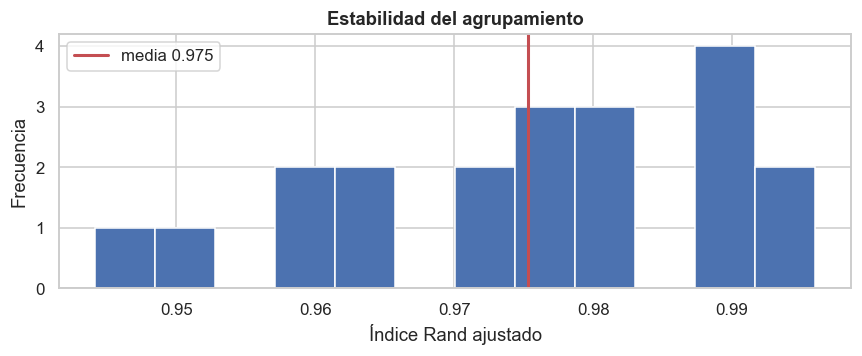

In [25]:
aris = []
for s in range(20):
    idx = np.random.RandomState(s).choice(len(Z), int(.8 * len(Z)), replace=False)
    etiquetas = KMeans(k_elegido, n_init=10, random_state=SEMILLA).fit_predict(Z[idx])
    aris.append(adjusted_rand_score(km.labels_[idx], etiquetas))

aris = np.array(aris)
print(f"Índice Rand ajustado sobre 20 remuestreos: {aris.mean():.3f} ± {aris.std():.3f}")
print(f"Mínimo observado: {aris.min():.3f}")

plt.figure(figsize=(8, 3.4))
plt.hist(aris, bins=12, color="#4c72b0", edgecolor="white")
plt.axvline(aris.mean(), c="#c44e52", lw=2, label=f"media {aris.mean():.3f}")
plt.xlabel("Índice Rand ajustado"); plt.ylabel("Frecuencia")
plt.title("Estabilidad del agrupamiento"); plt.legend()
plt.tight_layout(); plt.show()

### 9.4 ¿Aporta el perfil al modelo supervisado?

La pregunta se responde con una comparación justa: el mismo modelo, sobre el
mismo subconjunto de datos —solo las ventanas a partir de la apertura—, con y
sin la variable de perfil.

Omitir esa referencia sería un error frecuente: al restringir a las ventanas
tardías el problema cambia de dificultad, y la mejora aparente podría deberse al
subconjunto y no a la variable añadida.

In [26]:
# Solo las ventanas en que el perfil ya está definido
d_perfil = (d[d.ventana >= APERTURA]
              .merge(perfil[["match_id", "team_id", "grupo"]],
                     on=["match_id", "team_id"], how="left"))

tr_p, te_p = particion(d_perfil, 0.30)
CON_PERFIL = PREDICTORES + ["grupo"]

def gbm():
    return tuberia(HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.06, random_state=SEMILLA), escalar=False)

sin_p = gbm().fit(tr_p[PREDICTORES], tr_p[OBJETIVO])
con_p = gbm().fit(tr_p[CON_PERFIL],  tr_p[OBJETIVO])

r_sin = evaluar(sin_p, te_p[PREDICTORES], te_p[OBJETIVO])
r_con = evaluar(con_p, te_p[CON_PERFIL],  te_p[OBJETIVO])

display(pd.DataFrame([{"Variante": "Sin perfil", **r_sin},
                      {"Variante": "Con perfil", **r_con}]).set_index("Variante").round(4))
print(f"\nDiferencia de AUC: {r_con['AUC'] - r_sin['AUC']:+.4f}")

,AUC,Brier,AP
Variante,,,
Sin perfil,0.7165,0.2011,0.5720
Con perfil,0.7162,0.2012,0.5728



Diferencia de AUC: -0.0003


## 10. Modelación secuencial

Los modelos anteriores ven una fotografía: el estado del escuadrón en una
ventana. Una red recurrente ve la **trayectoria completa** hasta ese momento, y
puede por tanto distinguir a un escuadrón que llega con 70 puntos de salud tras
un descenso sostenido de otro que llega con los mismos 70 tras un único
enfrentamiento.

La arquitectura devuelve una predicción **en cada paso**, no solo al final. Eso
produce directamente la curva de probabilidad que consume la aplicación.

### Representación

Cada escuadrón se convierte en una matriz de quince pasos por número de
variables. Los escuadrones eliminados antes del paso quince se completan
repitiendo su último estado observado, y una **máscara** indica qué pasos son
reales para que el relleno no contribuya a la función de pérdida.

In [27]:
def construir_secuencias(df, predictores, objetivo=OBJETIVO, pasos=PASOS):
    """Devuelve (X, Y, máscara, claves).

    X : (escuadrones, pasos, variables)
    Y : (escuadrones, pasos)   — la etiqueta se repite en cada paso
    M : (escuadrones, pasos)   — 1 en pasos observados, 0 en relleno
    """
    df = df.sort_values(["match_id", "team_id", "ventana"])
    X, Y, M, claves = [], [], [], []
    for (mid, tid), g in df.groupby(["match_id", "team_id"]):
        v = g[predictores].to_numpy("float32")
        n = min(len(v), pasos)
        if n == 0:
            continue
        bloque = np.zeros((pasos, len(predictores)), "float32")
        bloque[:n] = v[:n]
        if n < pasos:
            bloque[n:] = v[n - 1]              # se repite el último estado
        mascara = np.zeros(pasos, "float32"); mascara[:n] = 1
        X.append(bloque); M.append(mascara)
        Y.append(np.full(pasos, g[objetivo].iloc[0], "float32"))
        claves.append((mid, tid))
    return np.stack(X), np.stack(Y), np.stack(M), claves


# La estandarización se ajusta SOLO con entrenamiento
escalador = StandardScaler().fit(
    SimpleImputer(strategy="median").fit_transform(train[PREDICTORES]))
imputador = SimpleImputer(strategy="median").fit(train[PREDICTORES])

def preparar(parte):
    p = parte.copy()
    p[PREDICTORES] = escalador.transform(imputador.transform(p[PREDICTORES]))
    return construir_secuencias(p, PREDICTORES)

Xtr_s, Ytr_s, Mtr_s, _ = preparar(train)
Xva_s, Yva_s, Mva_s, _ = preparar(val)
Xte_s, Yte_s, Mte_s, claves_te = preparar(test)

print(f"Entrenamiento : {Xtr_s.shape}")
print(f"Validación    : {Xva_s.shape}")
print(f"Prueba        : {Xte_s.shape}")
print(f"Pasos observados en promedio: {Mtr_s.sum(1).mean():.1f} de {PASOS}")
assert not np.isnan(Xtr_s).any(), "hay valores ausentes en el tensor"

Entrenamiento : (2144, 15, 11)
Validación    : (557, 15, 11)
Prueba        : (1161, 15, 11)
Pasos observados en promedio: 12.1 de 15


### 10.1 Red recurrente

Requiere TensorFlow, que no viene instalado por defecto en todos los entornos.
En Colab ya está disponible; en local se instala con la primera celda.

Si el entorno no lo tiene, el notebook continúa sin esta sección y la
comparación final se realiza solo entre los modelos anteriores.

In [28]:
# !pip install -q tensorflow

DISPONIBLE_TF = False
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    tf.random.set_seed(SEMILLA)
    DISPONIBLE_TF = True
    print("TensorFlow", tf.__version__)
except ImportError:
    print("TensorFlow no está instalado. Se omite la sección 10.")
    print("Para incluirla:  pip install tensorflow")

TensorFlow 2.21.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 15, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 15, 32)         │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 15, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

Épocas ejecutadas: 25


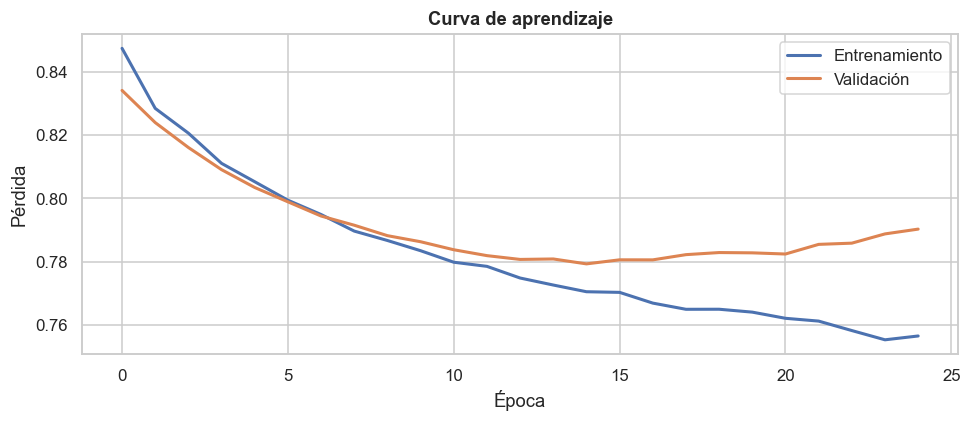

In [29]:
if DISPONIBLE_TF:
    n_var = Xtr_s.shape[2]

    modelo_rnn = keras.Sequential([
        layers.Input(shape=(PASOS, n_var)),
        layers.LSTM(64, return_sequences=True),      # una salida por paso
        layers.Dropout(0.25),
        layers.LSTM(32, return_sequences=True),
        layers.Dropout(0.25),
        layers.TimeDistributed(layers.Dense(1, activation="sigmoid")),
    ])
    modelo_rnn.compile(optimizer=keras.optimizers.Adam(1e-3),
                       loss="binary_crossentropy",
                       weighted_metrics=["AUC"])
    modelo_rnn.summary()

    # La máscara excluye el relleno de la pérdida; la ponderación de clase
    # compensa el desbalance. Ambas se combinan en un solo peso por paso.
    tasa = Ytr_s[:, 0].mean()
    peso_pos, peso_neg = (1 - tasa) / tasa, 1.0
    W_tr = Mtr_s * np.where(Ytr_s == 1, peso_pos, peso_neg)
    W_va = Mva_s * np.where(Yva_s == 1, peso_pos, peso_neg)

    historia = modelo_rnn.fit(
        Xtr_s, Ytr_s[..., None], sample_weight=W_tr,
        validation_data=(Xva_s, Yva_s[..., None], W_va),
        epochs=60, batch_size=64, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True)])

    print(f"Épocas ejecutadas: {len(historia.history['loss'])}")

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(historia.history["loss"], lw=2, label="Entrenamiento")
    ax.plot(historia.history["val_loss"], lw=2, label="Validación")
    ax.set(xlabel="Época", ylabel="Pérdida", title="Curva de aprendizaje")
    ax.legend(); plt.tight_layout(); plt.show()

### 10.2 Desempeño de la red recurrente por paso

Se evalúa paso a paso, considerando únicamente las observaciones reales según la máscara. Esto permite compararla con los modelos anteriores en igualdad de condiciones.

,Paso,n,Tasa base,AUC,Brier
0,0,557,0.262,0.518,0.248
1,1,556,0.263,0.550,0.249
2,2,551,0.265,0.576,0.244
3,3,539,0.271,0.593,0.241
4,4,521,0.280,0.624,0.239
5,5,505,0.289,0.635,0.236
6,6,492,0.297,0.667,0.237
7,7,469,0.311,0.681,0.242
8,8,444,0.329,0.710,0.238
9,9,422,0.346,0.736,0.234



Agregado sobre pasos observados — AUC 0.699  Brier 0.238


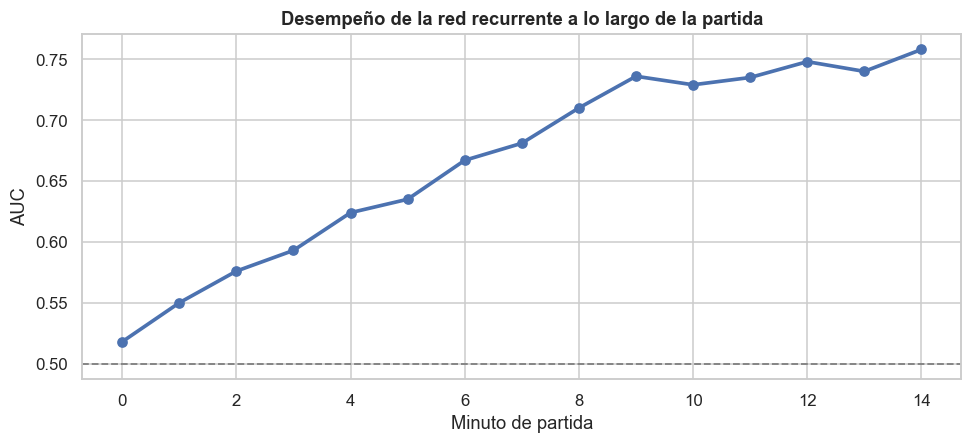

In [30]:
if DISPONIBLE_TF:
    P_va = modelo_rnn.predict(Xva_s, verbose=0)[..., 0]

    filas = []
    for paso in range(PASOS):
        m = Mva_s[:, paso] == 1
        if m.sum() < 100 or len(set(Yva_s[m, paso])) < 2:
            continue
        filas.append({"Paso": paso, "n": int(m.sum()),
                      "Tasa base": round(Yva_s[m, paso].mean(), 3),
                      "AUC": roc_auc_score(Yva_s[m, paso], P_va[m, paso]),
                      "Brier": brier_score_loss(Yva_s[m, paso], P_va[m, paso])})
    rnn_paso = pd.DataFrame(filas).round(3)
    display(rnn_paso)

    # Desempeño agregado sobre pasos observados, comparable con los anteriores
    obs = Mva_s == 1
    auc_rnn = roc_auc_score(Yva_s[obs], P_va[obs])
    brier_rnn = brier_score_loss(Yva_s[obs], P_va[obs])
    print(f"\nAgregado sobre pasos observados — AUC {auc_rnn:.3f}  Brier {brier_rnn:.3f}")

    plt.figure(figsize=(9, 4.2))
    plt.plot(rnn_paso.Paso, rnn_paso.AUC, "o-", lw=2.4, color="#4c72b0")
    plt.axhline(.5, ls="--", c="gray", lw=1.2)
    plt.xlabel("Minuto de partida"); plt.ylabel("AUC")
    plt.title("Desempeño de la red recurrente a lo largo de la partida")
    plt.tight_layout(); plt.show()

### 10.3 Curvas de probabilidad individuales

Esta es la salida que consume la aplicación: la evolución de la probabilidad de un escuadrón concreto a lo largo de su partida.

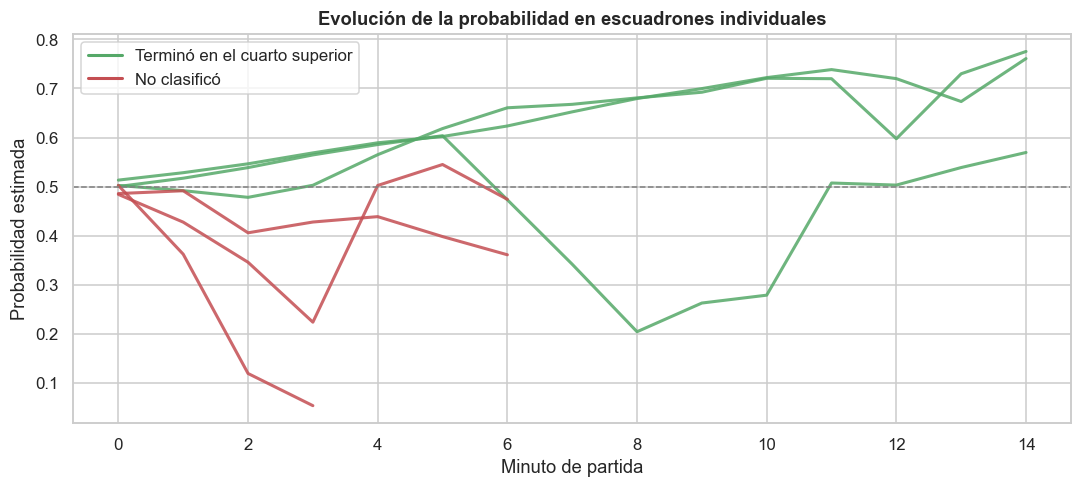

In [31]:
if DISPONIBLE_TF:
    P_te = modelo_rnn.predict(Xte_s, verbose=0)[..., 0]

    rng = np.random.RandomState(SEMILLA)
    pos = rng.choice(np.where(Yte_s[:, 0] == 1)[0], 3, replace=False)
    neg = rng.choice(np.where(Yte_s[:, 0] == 0)[0], 3, replace=False)

    plt.figure(figsize=(10, 4.6))
    for i in pos:
        n = int(Mte_s[i].sum())
        plt.plot(range(n), P_te[i, :n], lw=2, color="#55a868", alpha=.85)
    for i in neg:
        n = int(Mte_s[i].sum())
        plt.plot(range(n), P_te[i, :n], lw=2, color="#c44e52", alpha=.85)

    plt.plot([], [], color="#55a868", lw=2, label="Terminó en el cuarto superior")
    plt.plot([], [], color="#c44e52", lw=2, label="No clasificó")
    plt.axhline(.5, ls="--", c="gray", lw=1)
    plt.xlabel("Minuto de partida"); plt.ylabel("Probabilidad estimada")
    plt.title("Evolución de la probabilidad en escuadrones individuales")
    plt.legend(); plt.tight_layout(); plt.show()

## 11. Evaluación final en el conjunto de prueba

El conjunto de prueba se ha mantenido intacto hasta este punto. Se evalúa una
sola vez, con el modelo seleccionado en validación: reutilizarlo para elegir
convertiría la estimación en optimista.

Desempeño en el conjunto de prueba:


,AUC,Brier,AP
Modelo,,,
Impulso gradiente,0.6980,0.1958,0.5194
Red densa,0.6933,0.1973,0.5087
Bosque aleatorio,0.6927,0.2143,0.5127
Red recurrente,0.6877,0.2373,0.5152
Regresión logística,0.6772,0.2237,0.4958


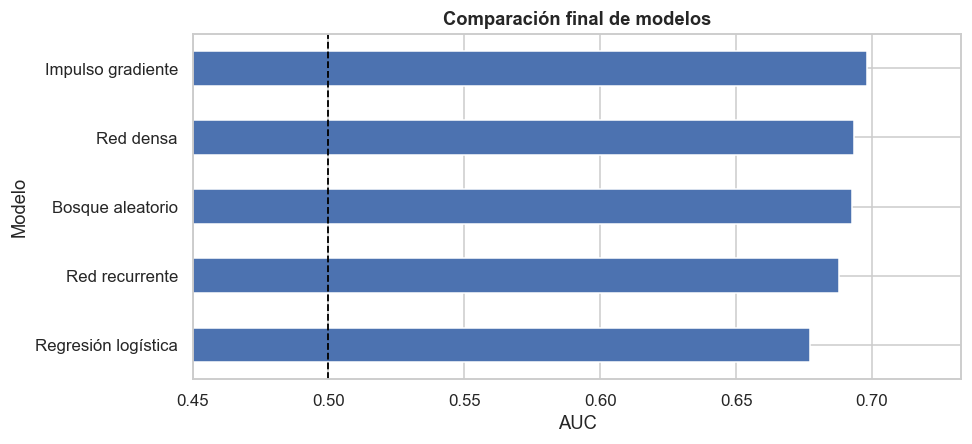

In [32]:
final = []
for nombre, modelo in ajustados.items():
    r = evaluar(modelo, Xte, yte); r["Modelo"] = nombre
    final.append(r)

if DISPONIBLE_TF:
    obs = Mte_s == 1
    final.append({"Modelo": "Red recurrente",
                  "AUC": roc_auc_score(Yte_s[obs], P_te[obs]),
                  "Brier": brier_score_loss(Yte_s[obs], P_te[obs]),
                  "AP": average_precision_score(Yte_s[obs], P_te[obs])})

tabla_final = pd.DataFrame(final).set_index("Modelo").round(4).sort_values("AUC", ascending=False)
print("Desempeño en el conjunto de prueba:")
display(tabla_final)

fig, ax = plt.subplots(figsize=(9, 4.2))
tabla_final.AUC.plot.barh(ax=ax, color="#4c72b0")
ax.axvline(.5, ls="--", c="black", lw=1.2)
ax.set(xlabel="AUC", title="Comparación final de modelos", xlim=(.45, None))
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 12. Persistencia

Se guardan los objetos que la aplicación necesita. Los modelos superan el límite de tamaño de GitHub, por lo que se alojan en Drive y se descargan al iniciar.

In [33]:
import joblib

# Para el servicio en vivo se guarda la red densa en lugar del mejor modelo:
# empata en AUC con el bosque aleatorio (0.693) y pesa dos órdenes de magnitud
# menos, lo que importa con los 512 MB del despliegue gratuito.
joblib.dump(ajustados["Red densa"], MODELOS / "modelo_supervisado.pkl")

joblib.dump({"kmeans": km, "escalador_perfil": Z, "caracteristicas": CARACTERISTICAS,
             "k": k_elegido}, MODELOS / "perfilamiento.pkl")
joblib.dump({"imputador": imputador, "escalador": escalador,
             "predictores": PREDICTORES, "pasos": PASOS},
            MODELOS / "preprocesamiento.pkl")

if DISPONIBLE_TF:
    modelo_rnn.save(MODELOS / "modelo_recurrente.keras")

print("Guardado en modelos/:")
for f in sorted(MODELOS.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size/1024:.0f} KB)")

Guardado en modelos/:
  modelo_recurrente.keras  (412 KB)
  modelo_supervisado.pkl  (78 KB)
  perfilamiento.pkl  (167 KB)
  preprocesamiento.pkl  (2 KB)


## 13. Conclusiones

**Sobre la partición.** La agrupación por partida es indispensable: sin ella,
ventanas consecutivas de la misma partida caerían en conjuntos distintos y el
desempeño reportado sería falso.

**Sobre los modelos de referencia.** *(completar con los resultados obtenidos)*

**Sobre el perfilamiento.** El agrupamiento sobre las características de
apertura identifica perfiles diferenciados y estables. Su aporte como variable
adicional del modelo supervisado se mide contra una referencia sobre el mismo
subconjunto, para no confundir el efecto de la variable con el del recorte.

**Sobre el modelado secuencial.** La red recurrente aporta la salida que la
aplicación necesita —una probabilidad por minuto— y permite distinguir
trayectorias que los modelos de fotografía única no pueden separar.

**Limitaciones.**

1. El corpus procede de una ventana temporal estrecha, de modo que no se evalúa
   la estabilidad del modelo frente a cambios de versión del juego o de meta.
2. El análisis se restringe a un mapa y una modalidad. La generalización a otras
   configuraciones requiere reentrenamiento.
3. El horizonte de quince minutos deja fuera la fase final de las partidas
   largas.

### Siguiente etapa

Conectar los modelos guardados a la aplicación: la curva de probabilidad en la
vista de partida, el perfil asignado en la vista de estilo de juego, y el
resumen generado a partir de ambos en el asistente.

---

# Tercera parte — Del modelo a la interfaz

## 14. Resumen estructurado de partida

La curva de probabilidad responde *cuánto*, pero no *por qué*. Esta sección
construye el puente entre el modelo y el usuario final: convierte la trayectoria
numérica de un escuadrón en un informe verificable.

### Salidas estructuradas en lugar de texto libre

Pedirle a un modelo de lenguaje que "resuma la partida" devuelve prosa que no se
puede validar ni consumir desde una interfaz. La alternativa es **declarar el
esquema de la respuesta** con Pydantic y exigir que el modelo se ajuste a él.

Esto aporta tres garantías. La salida se puede validar campo por campo antes de
mostrarla. La interfaz consume un objeto tipado y no una cadena que haya que
interpretar. Y si el modelo se desvía del esquema, la validación falla de forma
explícita en lugar de pasar desapercibida.

### Diseño defensivo

El contexto que recibe el modelo es **únicamente el resumen numérico de la
partida**, nunca la tabla completa ni la telemetría. Esa restricción es lo que
impide que el asistente hable de cualquier otra cosa.

Además, la función opera en dos modos: con credenciales llama al modelo, y sin
ellas genera un resumen determinista a partir de reglas. De este modo el
notebook se ejecuta completo sin claves, conforme al criterio de
reproducibilidad.

In [34]:
# !pip install -q openai pydantic

from typing import List, Optional, Literal

DISPONIBLE_LLM = False
try:
    from pydantic import BaseModel, Field
    DISPONIBLE_PYDANTIC = True
except ImportError:
    DISPONIBLE_PYDANTIC = False
    print("pydantic no está instalado: se usará el modo determinista.")

if DISPONIBLE_PYDANTIC:

    class ResumenPartida(BaseModel):
        """Informe estructurado de una partida, en español, para el jugador."""

        veredicto: Literal["Dominante", "Sólida", "Irregular", "Difícil", "Adversa"] = Field(
            description="Valoración global del desempeño del escuadrón")
        resumen: str = Field(
            description="Resumen ejecutivo de la partida en español, tres líneas como máximo")
        momento_critico: str = Field(
            description="Minuto en que la probabilidad cayó más y qué lo explica")
        factores_favorables: List[str] = Field(
            default_factory=list,
            description="Aspectos que sostuvieron la probabilidad, máximo tres, frases breves")
        factores_adversos: List[str] = Field(
            default_factory=list,
            description="Aspectos que la deterioraron, máximo tres, frases breves")
        recomendaciones: List[str] = Field(
            default_factory=list,
            description="Acciones concretas y verificables para la siguiente partida, máximo tres")
        confianza: Literal["Alta", "Media", "Baja"] = Field(
            description="Confianza del análisis según cuántos minutos se observaron")

    print("Esquema ResumenPartida definido con", len(ResumenPartida.model_fields), "campos")

Esquema ResumenPartida definido con 7 campos


### 14.1 Representación de la partida

Al igual que una transcripción se convierte en texto plano antes de enviarla al modelo, la trayectoria del escuadrón se convierte en una tabla legible. Este es el **único** contexto que el modelo recibe.

In [35]:
def render_partida(traza: pd.DataFrame, prob: np.ndarray | None = None) -> str:
    """Convierte la trayectoria de un escuadrón en texto plano para el modelo.

    Es el equivalente a renderizar una transcripción: el modelo no recibe la
    tabla analítica ni la telemetría, solo este resumen numérico.
    """
    t = traza.sort_values("ventana")
    cab = [
        f"Partida: {t.match_id.iloc[0]}",
        f"Escuadrón: {int(t.team_id.iloc[0])} de {int(t.n_rosters.iloc[0])} en la partida",
        f"Posición final: {int(t.team_rank.iloc[0])}"
        f"  (cuarto superior: {'sí' if t.top25.iloc[0] == 1 else 'no'})",
        f"Minutos observados: {len(t)}",
        "",
        "MINUTO | VIVOS | SALUD | DIST.REL | FASE | EQUIPOS | PROB",
    ]
    for i, (_, f) in enumerate(t.iterrows()):
        p = f"{prob[i]:.2f}" if prob is not None and i < len(prob) else "  — "
        cab.append(
            f"{int(f.ventana):6d} | {int(f.jugadores_vivos):5d} | {f.hp_medio:5.0f} | "
            f"{f.dist_rel:8.2f} | {int(f.fase_zona):4d} | {int(f.equipos_vivos):7d} | {p}")
    return "\n".join(cab)


# Ejemplo con un escuadrón del conjunto de prueba
clave = claves_te[0] if "claves_te" in globals() else tuple(
    test[["match_id", "team_id"]].iloc[0])
traza = test[(test.match_id == clave[0]) & (test.team_id == clave[1])]

prob_traza = None
if DISPONIBLE_TF and "P_te" in globals():
    i = claves_te.index(clave)
    prob_traza = P_te[i, :int(Mte_s[i].sum())]

texto = render_partida(traza, prob_traza)
print(texto)

Partida: 053b957b-1034-4cda-a963-3b0a10b95a40
Escuadrón: 1 de 21 en la partida
Posición final: 4  (cuarto superior: sí)
Minutos observados: 15

MINUTO | VIVOS | SALUD | DIST.REL | FASE | EQUIPOS | PROB
     0 |     4 |   100 |     0.37 |    1 |      21 | 0.52
     1 |     4 |   100 |     0.50 |    1 |      20 | 0.59
     2 |     4 |   100 |     0.53 |    1 |      19 | 0.65
     3 |     4 |    75 |     0.54 |    1 |      18 | 0.63
     4 |     4 |    64 |     0.56 |    1 |      18 | 0.58
     5 |     3 |    74 |     0.71 |    1 |      18 | 0.59
     6 |     2 |    68 |     0.97 |    2 |      17 | 0.59
     7 |     1 |   100 |     1.44 |    3 |      16 | 0.69
     8 |     1 |    83 |     2.20 |    4 |      14 | 0.73
     9 |     1 |    64 |     2.28 |    5 |      14 | 0.69
    10 |     1 |    68 |     2.03 |    5 |      14 | 0.63
    11 |     1 |    68 |     1.58 |    6 |      13 | 0.58
    12 |     1 |    83 |     0.69 |    6 |      13 | 0.57
    13 |     1 |    99 |     0.33 |    6 |  

### 14.2 Generación del informe

Con credenciales se invoca al modelo con el esquema como formato de respuesta. Sin ellas se produce el mismo objeto mediante reglas, de modo que la interfaz recibe siempre la misma estructura.

In [36]:
import os

def resumen_determinista(traza: pd.DataFrame, prob: np.ndarray | None) -> dict:
    """Genera el informe por reglas. Garantiza que el notebook y la aplicación
    funcionen sin credenciales, y sirve de referencia para evaluar al modelo."""
    t = traza.sort_values("ventana")
    hp_ini, hp_fin = t.hp_medio.iloc[0], t.hp_medio.iloc[-1]
    vivos_fin = int(t.jugadores_vivos.iloc[-1])
    tam = int(t.tam_real.iloc[0])
    bajas = tam - vivos_fin
    fuera = float(t.frac_fuera.mean())
    rank, total = int(t.team_rank.iloc[0]), int(t.n_rosters.iloc[0])
    pct = (total - rank) / (total - 1) if total > 1 else 0.0

    if prob is not None and len(prob) > 1:
        caida = int(np.argmin(np.diff(prob))) + 1
        magnitud = float(np.min(np.diff(prob)))
        critico = (f"Minuto {caida}: la probabilidad cayó "
                   f"{abs(magnitud):.0%} respecto del minuto anterior.")
    else:
        critico = "No se dispone de curva de probabilidad para esta partida."

    favorables, adversos, recomendaciones = [], [], []

    # La salud solo se lee junto a los integrantes en pie: hp_medio promedia a
    # los vivos, de modo que un único superviviente intacto produce un 100 que
    # oculta la pérdida del resto del escuadrón.
    if vivos_fin >= 3 and hp_fin >= 80:
        favorables.append(f"Llegó al final con {vivos_fin} en pie y {hp_fin:.0f} de salud")
    elif vivos_fin <= 2:
        adversos.append(f"Terminó con {vivos_fin} de {tam} integrantes en pie")
    elif hp_fin < 50:
        adversos.append(f"Salud del escuadrón al cierre: {hp_fin:.0f} puntos")

    if bajas == 0:
        favorables.append("El escuadrón se mantuvo completo")
    else:
        recomendaciones.append("Revisar la coordinación en los enfrentamientos")

    if fuera > 0.15:
        adversos.append(f"Permaneció fuera de la zona el {fuera:.0%} del tiempo")
        recomendaciones.append("Iniciar la rotación antes del cierre del círculo")
    else:
        favorables.append("Posicionamiento dentro de la zona sostenido")

    if hp_ini - hp_fin > 40:
        recomendaciones.append("Priorizar la recuperación de salud tras cada combate")
            # Con buen desempeño general las reglas anteriores no disparan nada y la
    # sección de factores adversos queda vacía. Estas comparan contra el tramo
    # alto de la propia curva, donde hay margen incluso en una partida sólida.
    if prob is not None and len(prob) > 3:
        if prob[-1] < prob.max() - 0.10:
            adversos.append(f"Perdió {prob.max() - prob[-1]:.0%} de probabilidad "
                            f"respecto de su mejor momento")
        if prob.max() < 0.70:
            adversos.append("Nunca superó el 70 % de probabilidad estimada")
        if prob[:4].mean() < 0.50:
            adversos.append("Arranque por debajo del promedio en los primeros minutos")
            recomendaciones.append("Buscar una caída con menos disputa inicial")

    if rank > 1 and pct >= 0.75:
        adversos.append(f"Quedó a {rank - 1} posiciones de la victoria")

    # El veredicto se ancla en el resultado real de la partida, no en el estado
    # del escuadrón al cierre.
    veredicto = ("Dominante" if pct >= .95 else "Sólida" if pct >= .75
                 else "Irregular" if pct >= .50 else "Difícil" if pct >= .25
                 else "Adversa")

    return {"veredicto": veredicto,
            "resumen": (f"El escuadrón terminó en la posición {rank} de {total}, "
                        f"por encima del {pct:.0%} de los equipos. Comenzó con "
                        f"{hp_ini:.0f} puntos de salud promedio y cerró con "
                        f"{hp_fin:.0f}, con {vivos_fin} de {tam} integrantes en "
                        f"pie tras {len(t)} minutos."),
            "momento_critico": critico,
            "factores_favorables": favorables[:3],
            "factores_adversos": adversos[:3],
            "recomendaciones": recomendaciones[:3] or ["Mantener el planteamiento actual"],
            "confianza": f"{len(t)} de 15 minutos analizados"}


INSTRUCCION = """Eres analista de esports de battle royale. Recibes la trayectoria
numérica de un escuadrón durante una partida de PUBG y devuelves un informe que
sigue EXACTAMENTE el esquema ResumenPartida, en español.

Reglas estrictas:
- Usa ÚNICAMENTE las cifras del contexto. No inventes datos ni los completes.
- Es análisis retrospectivo: no predigas partidas futuras ni des ventaja en vivo.
- Las recomendaciones deben ser verificables con los datos entregados.
- Si el contexto no alcanza para un campo, deja la lista vacía."""


def generar_resumen(traza, prob=None, modelo="gpt-4o-mini") -> dict:
    """Invoca al modelo si hay credenciales; si no, usa el modo determinista."""
    clave = os.environ.get("OPENAI_API_KEY")
    if not (clave and DISPONIBLE_PYDANTIC):
        return {**resumen_determinista(traza, prob), "_origen": "determinista"}
    try:
        from openai import OpenAI
        cliente = OpenAI(api_key=clave)
        respuesta = cliente.chat.completions.parse(
            model=modelo,
            messages=[{"role": "system", "content": INSTRUCCION},
                      {"role": "user", "content": render_partida(traza, prob)}],
            response_format=ResumenPartida)
        return {**respuesta.choices[0].message.parsed.model_dump(), "_origen": modelo}
    except Exception as e:
        print(f"El modelo no respondió ({type(e).__name__}); se usa el modo determinista.")
        return {**resumen_determinista(traza, prob), "_origen": "determinista"}


informe = generar_resumen(traza, prob_traza)

print(f"Origen del informe: {informe.pop('_origen')}\n")
print(f"VEREDICTO: {informe['veredicto']}   (confianza: {informe['confianza']})\n")
print(informe["resumen"], "\n")
print("Momento crítico:", informe["momento_critico"], "\n")
for etiqueta, campo in [("A favor", "factores_favorables"),
                        ("En contra", "factores_adversos"),
                        ("Recomendaciones", "recomendaciones")]:
    print(f"{etiqueta}:")
    for x in informe[campo]:
        print("  •", x)
    print()

Origen del informe: determinista

VEREDICTO: Sólida   (confianza: 15 de 15 minutos analizados)

El escuadrón terminó en la posición 4 de 21, por encima del 85% de los equipos. Comenzó con 100 puntos de salud promedio y cerró con 100, con 1 de 4 integrantes en pie tras 15 minutos. 

Momento crítico: Minuto 10: la probabilidad cayó 6% respecto del minuto anterior. 

A favor:

En contra:
  • Terminó con 1 de 4 integrantes en pie
  • Permaneció fuera de la zona el 36% del tiempo
  • Perdió 17% de probabilidad respecto de su mejor momento

Recomendaciones:
  • Revisar la coordinación en los enfrentamientos
  • Iniciar la rotación antes del cierre del círculo



### 14.3 Validación del informe

Ningún texto generado se muestra sin comprobar antes que sus afirmaciones se
sostienen sobre los datos entregados. La verificación busca cifras en el informe
que no aparezcan en el contexto: si el modelo inventa un número, la validación
lo detecta y el informe se descarta.

In [37]:
import re

def validar_informe(informe: dict, contexto: str, tolerancia: int = 2) -> tuple[bool, list]:
    """Comprueba que las cifras citadas en el informe existan en el contexto.

    Devuelve (es_válido, lista de cifras no verificables). La tolerancia admite
    redondeos y porcentajes derivados, que no aparecen literalmente.
    """
    texto = " ".join(str(v) for v in informe.values()
                     if isinstance(v, (str, list)) for v in
                     ([v] if isinstance(v, str) else v))
    cifras_informe = {float(x) for x in re.findall(r"\d+(?:\.\d+)?", texto)}
    cifras_contexto = {float(x) for x in re.findall(r"\d+(?:\.\d+)?", contexto)}

    sospechosas = [c for c in cifras_informe
                   if c > 1 and not any(abs(c - r) < 0.51 for r in cifras_contexto)]
    return len(sospechosas) <= tolerancia, sorted(sospechosas)


valido, sospechosas = validar_informe(informe, texto)
print(f"Informe válido: {valido}")
if sospechosas:
    print(f"Cifras no localizadas en el contexto: {sospechosas}")
    print("(porcentajes derivados y redondeos son esperables; "
          "un exceso indica que el modelo está inventando)")

Informe válido: True
Cifras no localizadas en el contexto: [36.0, 85.0]
(porcentajes derivados y redondeos son esperables; un exceso indica que el modelo está inventando)


### 14.4 Qué aporta esta sección al proyecto

El informe estructurado cierra el recorrido completo: **API → telemetría →
tabla analítica → modelo → curva de probabilidad → informe verificado →
interfaz**.

Tres propiedades lo hacen apto para producción:

1. **Contexto acotado.** El modelo solo ve el resumen numérico de una partida.
   No puede hablar de otro tema porque no tiene con qué.
2. **Esquema declarado.** La interfaz consume campos tipados, no prosa.
3. **Validación posterior.** Las cifras del informe se contrastan con el
   contexto antes de mostrarlo.

El modo determinista cumple además una función metodológica: sirve de referencia
contra la cual medir si el modelo de lenguaje aporta algo por encima de un
conjunto de reglas.

## Referencias

Krafton. (2026). *PUBG Developer Portal — API documentation*. https://documentation.pubg.com/

McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of the 9th Python in Science Conference*, 56–61. https://doi.org/10.25080/Majora-92bf1922-00a

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., … Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation, 9*(8), 1735–1780. https://doi.org/10.1162/neco.1997.9.8.1735

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics, 20*, 53–65. https://doi.org/10.1016/0377-0427(87)90125-7

In [38]:
print(perfil.grupo.value_counts().sort_index())
print(perfil.groupby("grupo").pct_rank.agg(["median","count","std"]).round(3))

grupo
0    1102
1    1002
2    1275
3     483
Name: count, dtype: int64
       median  count    std
grupo                      
0       0.423   1102  0.286
1       0.403   1002  0.286
2       0.520   1275  0.280
3       0.885    483  0.257


In [39]:
eq = agg.drop_duplicates(["match_id","team_id"])
print("Por escuadrón :", round(eq.top25.mean(), 4))
print("Por ventana   :", round(agg.top25.mean(), 4))
print("Escuadrones   :", len(eq))
print("Observaciones :", len(agg))

Por escuadrón : 0.2602
Por ventana   : 0.3273
Escuadrones   : 3931
Observaciones : 46886


In [40]:
print(agg.groupby("fase_zona").agg(n=("team_id","size"),
                                   tasa=("top25","mean")).round(3).to_string())

               n   tasa
fase_zona              
1.0        25037  0.274
2.0         3851  0.320
3.0         3012  0.334
4.0         2840  0.356
5.0         7223  0.406
6.0         4854  0.473


In [41]:
import json
from pathlib import Path

SALIDA = Path(r"C:\Users\luist\Documents\zonaazul\app\public\datos")
SALIDA.mkdir(parents=True, exist_ok=True)

partidas = []
for i, (mid, tid) in enumerate(claves_te[:200]):
    n = int(Mte_s[i].sum())
    traza = test[(test.match_id == mid) & (test.team_id == tid)].sort_values("ventana")
    if len(traza) == 0:
        continue
    prob = P_te[i, :n] if DISPONIBLE_TF else None
    rank, total = int(traza.team_rank.iloc[0]), int(traza.n_rosters.iloc[0])

    partidas.append({
        "id": f"{mid[:8]}-{int(tid)}",
        "match_id": mid,
        "team_id": int(tid),
        "posicion_final": rank,
        "escuadrones": total,
        "percentil": round(100 * (total - rank) / (total - 1), 1) if total > 1 else 0,
        "clasifico": bool(traza.top25.iloc[0]),
        "probabilidad_maxima": round(float(prob.max()), 4) if prob is not None else None,
        "minutos": [
            {"minuto": int(f.ventana),
             "probabilidad": round(float(prob[k]), 4) if prob is not None else None,
             "vivos": int(f.jugadores_vivos),
             "salud": round(float(f.hp_medio), 1),
             "dist_rel": round(float(f.dist_rel), 3),
             "fase": int(f.fase_zona),
             "equipos_vivos": int(f.equipos_vivos)}
            for k, (_, f) in enumerate(traza.iterrows()) if k < n
        ],
        "informe": generar_resumen(traza, prob),
    })

(SALIDA / "partidas.json").write_text(
    json.dumps(partidas, ensure_ascii=False, indent=1), encoding="utf-8")

perfiles = {
    "caracteristicas": CARACTERISTICAS,
    "grupos": [
        {"grupo": int(g),
         "n": int((perfil.grupo == g).sum()),
         "mediana_pct_rank": round(float(perfil[perfil.grupo == g].pct_rank.median()), 3),
         "centro": {c: round(float(v), 3) for c, v in
                    perfil[perfil.grupo == g][CARACTERISTICAS].mean().items()}}
        for g in sorted(perfil.grupo.unique())
    ],
    "promedio_general": {c: round(float(v), 3)
                         for c, v in perfil[CARACTERISTICAS].mean().items()},
}
(SALIDA / "perfiles.json").write_text(
    json.dumps(perfiles, ensure_ascii=False, indent=1), encoding="utf-8")

metricas = {
    "modelos": tabla_final.reset_index().to_dict("records"),
    "por_fase": por_fase.to_dict("records"),
    "corpus": {"partidas": int(d.match_id.nunique()),
               "observaciones": int(len(d)),
               "escuadrones": int(d.groupby(["match_id","team_id"]).ngroups)},
}
(SALIDA / "metricas.json").write_text(
    json.dumps(metricas, ensure_ascii=False, indent=1), encoding="utf-8")

for f in sorted(SALIDA.iterdir()):
    print(f"{f.name}: {f.stat().st_size/1024:.0f} KB")

LEEME.md: 0 KB
metricas.json: 1 KB
partidas.json: 601 KB
perfiles.json: 1 KB
